# Jigsaw Unintended Bias in Toxicity Classification
## Détection de toxicité robuste et atténuation des biais d'identité

### Enoncé du problème
Les plateformes en lignes modèrent automatiquement les
commentaires pour limiter les messages haineux. Mais ces classifieurs de
toxicité présentent souvent un biais : ils ont tendance à considérer certains mots
liés à des identités ou communautés (par exemple « gay », « black », « muslim
») comme intrinsèquement toxiques. Cela entraîne une censure injuste qui
touche en priorité des groupes marginalisés.
Notre objectif est donc de développer un modèle de détection de la toxicité qui
reste efficace pour modérer les propos haineux, tout en réduisant au maximum
ces biais involontaires, afin de garantir une modération plus juste.

### Pertinence pour le Big Data

Le dataset contient environ 2.0 millions de
commentaires annotés avec des metadonnées sur les biais potentiels).
L’approche Big Data est nécessaire car :

Volume : 2.38GB de données dont environ 2.0 millions de commentaires
(texte libre) avec des colonnes de labels binaires et continus.
Variété :
- Données non struturées : texte brut nécessitant un prétraitement
lourd afin de pouvoir les exploiter
- Données structurées : variables numériques (binaires/continues)
liées aux biais (genre, religion, orientation sexuelle)
- Nécessite des pipelines capables d’intégrer ces différents types de
données

Vélocité : dans un scénario de déploiement, les plateformes en lignes
génèrent des flux continus de nouveaux commentaires
- Nécessite une modération en temps réel ce qui impose des
systèmes distribués de type stream processing pour l’ingestion, le
prétraitement des données et la classification

Limitations des approches traditionnelles : L’approche traditionnelle
Pandas/Scikit-learn qui fonctionne en mémoire sur un seul CPU est
inadapté pour l’entraînement sur plusieurs millions de commentaires en
texte brut. HDFS + Spark nous permettront de faire de la parallélisation
pour entraîner les NLP.

### Description de l'ensemble de données

Dataset Name: Jigsaw Unintended Bias in Toxicity Classification

Source: Compétition Kaggle https://www.kaggle.com/competitions/jigsaw-unintended-bias-in-toxicity-classification/overview

Type of Data: Semi-structuré (texte brut en CSV + colonnes numériques,
binaires)

Volume: 2 millions de commentaires annotés ; 2.38GB de données dans tous
les fichiers

Key Features:
- comment_text : commentaires (texte brut)
- target : score de toxicité (0-1)
- l’ensembles des colonnes du dataset identity_individual_annotations (double entre 0 et 1 pour la plupart mais aussi timestamp, integer et string)

Activation de findspark 

imports spark 

création de la session Spark : 
- utilisation de tous les coeurs alloués à la vm
- on alloue 8g de RAM à spark

In [1]:
import findspark
findspark.init()

import pyspark
from pyspark.sql import SparkSession

spark = SparkSession.builder \
.master("local[*]") \
.appName("Jigsaw Unintended Bias in Toxicity Classification") \
.config("spark.driver.memory", "8g") \
.config("spark.driver.maxResultSize", "2g") \
.config("spark.executor.memory", "8g") \
.config("spark.sql.shuffle.partitions", "8") \
.config("spark.network.timeout", "600s") \
.config("spark.some.config.option", "some-value") \
.getOrCreate()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/12/04 20:35:17 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


**Imports**: matplotlib pour les graphiques ; des fonctions de pyspark.sql ; des fonctions de pyspark.ml pour la création de pipeline ; nltk et WordNet Lemmatizer pour la lemmatisation ; PipelineModel pour le chargement et la sauvegarde d'un pipeline spark

In [2]:
print(spark.version)
import matplotlib.pyplot as plt
from pyspark.sql.functions import isnan

from pyspark.sql.functions import udf, regexp_replace, lower, col, when, isnan
from pyspark.sql.types import ArrayType, StringType
from pyspark.ml import Pipeline
from pyspark.ml.feature import Tokenizer, StopWordsRemover, SQLTransformer
from pyspark.ml.evaluation import BinaryClassificationEvaluator

import nltk
nltk.download("wordnet")
nltk.download("omw-1.4")
from nltk.stem import WordNetLemmatizer

import os
import json
from pyspark.ml import PipelineModel

from pyspark.ml.feature import CountVectorizer, IDF
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier, LinearSVC, GBTClassifier
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder


4.0.0


[nltk_data] Downloading package wordnet to /home/vboxuser/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /home/vboxuser/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


# 0. Chargement et inspection des données

In [3]:
# train = spark.read.csv('../train.csv', header=True, inferSchema=True)
# train.select("id", "target", "comment_text").show(5, truncate=False) # pas toutes les colonnes sinon illible 

On print le schéma ainsi que la desccription de certaines colonnes pour vérifier si spark a correctement inféré les types des features

In [4]:
# train.printSchema()

# print(f"nombre de lignes : {train.count()}")
# print(f"nombre de colonnes : {len(train.columns)}")
# train.describe(['target', 'severe_toxicity', 'obscene', 'insult']).show()

Problème : on a des données non numériques dans ces colonnes --> données mal parsées ; de plus on a dans le schéma : type string au lieu d'un type numérique, ce qui confirme notre intuition. Nous réadaptons le script en conséquence :

In [5]:
train = (
    spark.read.format("csv")
    .option("header", True)
    .option("inferSchema", True)
    .option("multiLine", True) # commentaires multilignes
    .option("escape", "\"") # les " internes à un comment ne ferment pas le champ
    .load("../train.csv")
)

In [6]:
# train.printSchema()

In [7]:
# print(f"nombre de lignes : {train.count()}")
# print(f"nombre de colonnes : {len(train.columns)}")
# train.describe(['target', 'severe_toxicity', 'obscene', 'insult']).show()

Les features ont été correctement inférées. La moyenne ainsi que l'écart type de ces features nous renseigne quand à un fort déséquilibre des classes, que nous approfondirons par la suite

In [8]:
# train.limit(20).toPandas().head()

A l'aide du schéma on identifie des groupes dans les features :

- La colonne commentaires --> **string**
- La colonne target --> **double entre [0,1]**
- Les sous-labels de toxicité --> **double entre [0,1]** : <span style="color:green;">severe_toxicity, obscene, identity_attack, insult, threat, sexual_explicit
</span>



- Les colonnes d'identité --> **float entre [0,1]** : <span style="color:green;">asian, atheist, bisexual, black, buddhist, christian, female, heterosexual, hindu, homosexual_gay_or_lesbian, intellectual_or_learning_disability, jewish, latino, male, muslim, other_disability, other_gender, other_race_or_ethnicity, other_religion, other_sexual_orientation, physical_disability, psychiatric_or_mental_illness, transgender, white</span>
 
- Les colonnes temporelles --> **timestamp** : <span style="color:green;">created_date</span>


- Les features liées aux métadonnées --> **numériques mais catégorielles** : <span style="color:green;">publication_id, parent_id, article_id</span>

- Colonnes liées aux réactions --> compteurs d’interactions, **int** : <span style="color:green;">funny, wow, sad, likes, disagree</span>

- Nombre d'annotateurs sur un commentaire donné (mesure de la confiance des labels) --> **int** : <span style="color:green;">identity_annotator_count, toxicity_annotator_count</span>

*Nous allons explorer les distributions de toutes ces colonnes. Sont affichées ci-dessous tous les distributions pour chaque feature représentative d'un groupe*


Fonction pour afficher la distribution d'une col numerique + nb valeurs manquantes

In [9]:
def describe_col(spark_df, column_name, bins = 50):
    """
    Affiche la distribution d'une col numerique + nb valeurs manquantes
    """
    data = spark_df.select(column_name).toPandas()
    
    plt.figure(figsize=(8, 5))
    plt.hist(data[column_name], bins=bins, edgecolor='black')
    plt.title(f"Distribution de '{column_name}'")
    plt.xlabel(column_name)
    plt.ylabel("Fréquence")
    plt.grid(True, alpha=0.3)
    plt.show()

    tot = spark_df.count()

    dtype = dict(spark_df.dtypes)[column_name]

    if dtype in ("double", "float"):
        missing = spark_df.filter(
            col(column_name).isNull() | isnan(col(column_name))
        ).count()
    else:
        missing = spark_df.filter(
            col(column_name).isNull()
        ).count()

    missing_pct = (missing / tot) * 100
    print(f"Valeurs manquantes : {missing} / {tot} ({missing_pct:.2f}%)")

In [10]:
from pyspark.sql.functions import col, isnan, lit
import numpy as np

def preview_comments(df, col_name, comment_col="comment_text", max_categories=5, bins=5, per_group=3):
    """
    Aperçu des commentaires :
    - Si nombre de valeurs distinctes inf ou egal à max_categories --> catégoriel
    - Sinon --> continu, on fait des bins
    --> Affiche un tableau récapitulatif des effectifs
    """

    # On compte le nb de valeurs distinctes
    distinct_vals = df.select(col_name).distinct().dropna().collect()
    distinct_count = len(distinct_vals)

    print(f"Nombre de valeurs distinctes : {distinct_count}\n")

    # VARIABLE CATÉGORIELLE
    if distinct_count <= max_categories:
        print("--> Colonne détectée comme CATEGORIELLE\n")

        values = [row[col_name] for row in distinct_vals]

        # tableau des effectifs 
        summary_rows = []
        for v in values:
            count_v = df.filter(col(col_name) == v).count()
            summary_rows.append((str(v), count_v))

        summary_df = spark.createDataFrame(summary_rows, ["Categorie", "Effectif"])
        print("Tableau des effectifs par catégorie :")
        summary_df.show(truncate=False)

        print("\nAperçu des commentaires par catégorie :\n")

        for v in values:
            print(f">> Valeur : {v} ")
            subset = df.filter(col(col_name) == v)
            subset.select(col_name, comment_col).show(per_group, truncate=100)
            print("\n")

        return


    # VARIABLE CONTINUE
    print("--> Colonne détectée comme CONTINUE (ou + de 5 catégories). Création de bins.\n")

    # on cherche min/max
    values = df.select(col_name).dropna().rdd.map(lambda r: r[0]).collect()
    mn, mx = min(values), max(values)

    print(f"Range = [{mn:.4f}, {mx:.4f}]\n")

    edges = np.linspace(mn, mx, bins + 1)

    # tableau des effectifs par bin 
    summary_rows = []

    for i in range(bins):
        low, high = float(edges[i]), float(edges[i+1])

        # Tous les bins sauf le dernier : [low, high)
        if i < bins - 1:
            subset = df.filter((col(col_name) >= low) & (col(col_name) < high))
        else:
            # Dernier bin : inclut la valeur max --> sinon on a pas les val avec 1.0 quand les valeurs sont entre [0,1]
            subset = df.filter((col(col_name) >= low) & (col(col_name) <= high))

        count_bin = subset.count()
        summary_rows.append((f"[{low:.4f}, {high:.4f}]", count_bin))

    summary_df = spark.createDataFrame(summary_rows, ["Intervalle", "Effectif"])

    print("Tableau des effectifs par intervalle :")
    summary_df.show(truncate=False)
    print("\nAperçu des commentaires par bin :\n")


    # Affichage des commentaires par bin
    for i in range(bins):
        low, high = float(edges[i]), float(edges[i+1])
        print(f">> Intervalle {i+1}/{bins} : [{low:.4f}, {high:.4f}] ")

        if i < bins - 1:
            subset = df.filter((col(col_name) >= low) & (col(col_name) < high))
        else:
            subset = df.filter((col(col_name) >= low) & (col(col_name) <= high))

        subset.select(col_name, comment_col).show(per_group, truncate=100)
        print("\n")

In [11]:
from pyspark.sql.functions import col

def explore_categorical(df, col_name="rating", comment_col="comment_text", per_group=5):
    print(f">> Exploration de la colonne catégorielle : {col_name} \n")

    # Valeurs distinctes + effectifs
    summary = (
        df.groupBy(col_name)
          .count()
          .orderBy(col("count").desc())
    )

    print("Valeurs et effectifs :")
    summary.show(truncate=False)

    # Aperçu des exemples par catégorie
    categories = [row[col_name] for row in summary.collect()]

    print("\n>> Aperçu des commentaires par catégorie \n")
    for cat in categories:
        print(f">> {col_name} = '{cat}'")
        df.filter(col(col_name) == cat) \
          .select(col_name, comment_col) \
          .show(per_group, truncate=100)
        print("\n")


In [12]:
# describe_col(train, column_name="target")
# preview_comments(train, "target")

In [13]:
# describe_col(train, "severe_toxicity")
# preview_comments(train, "severe_toxicity")


In [14]:
# describe_col(train, "asian")
# preview_comments(train, "asian")

In [15]:
# describe_col(train, "created_date")

In [16]:
# describe_col(train, "publication_id")

In [17]:
# describe_col(train, "parent_id")

In [18]:
# describe_col(train, "article_id")

In [19]:
# describe_col(train, "funny")
# preview_comments(train, "funny")

In [20]:
# describe_col(train, "identity_annotator_count")
# preview_comments(train, "identity_annotator_count")

In [21]:
# explore_categorical(train, "rating", comment_col="comment_text")

In [22]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.stat import Correlation
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def heatmap_with_col(df, col_main, other_cols, method="pearson", sample_fraction=0.1, seed=42):
    """
    Affiche une heatmap de corrélation entre col_main et d'autres colonnes.
    """
    cols = [col_main] + other_cols
    
    # Échantillonnage pour rapidité
    sampled_df = df.select(cols).dropna().sample(fraction=sample_fraction, seed=seed)
    
    # Convertir en pandas
    pdf = sampled_df.toPandas()
    
    # Calculer la corrélation
    corr_matrix = pdf.corr(method=method)
    
    # Extraire uniquement la colonne principale vs les autres
    corr_series = corr_matrix[col_main].drop(col_main)
    
    # Affichage heatmap
    plt.figure(figsize=(8, max(4, len(other_cols)*0.5)))
    sns.heatmap(corr_series.to_frame(), annot=True, cmap="coolwarm", vmin=-1, vmax=1)
    plt.title(f"Correlation avec {col_main}")
    plt.show()


In [23]:
# numeric_cols = [
#     "severe_toxicity", "obscene", "identity_attack", "insult", "threat",
#     "asian", "atheist", "bisexual", "black", "buddhist", "christian",
#     "female", "heterosexual", "hindu", "homosexual_gay_or_lesbian",
#     "intellectual_or_learning_disability", "jewish", "latino", "male",
#     "muslim", "other_disability", "other_gender", "other_race_or_ethnicity",
#     "other_religion", "other_sexual_orientation", "physical_disability",
#     "psychiatric_or_mental_illness", "transgender", "white",
#     "funny", "wow", "sad", "likes", "disagree", "sexual_explicit",
#     "identity_annotator_count", "toxicity_annotator_count",
#     "publication_id", "parent_id", "article_id"
# ]

# heatmap_with_col(train, "target", numeric_cols, sample_fraction=0.1)

In [24]:
import matplotlib.pyplot as plt
import numpy as np

def scatter_plot(df, col_x, col_y, sample_fraction=0.1, seed=42, title=None, show_regression=True):
    """
    Affiche un scatter plot entre deux colonnes numériques et éventuellement la droite de régression.
    """
    # echantillonage
    sampled_df = df.select(col_x, col_y).dropna().sample(fraction=sample_fraction, seed=seed)
    
    # on passe en pandas
    pdf = sampled_df.toPandas()
    
    plt.figure(figsize=(6,5))
    plt.scatter(pdf[col_x], pdf[col_y], alpha=0.6, s=20, label="Données")

    # droite de regression 
    if show_regression:
        x = pdf[col_x].values
        y = pdf[col_y].values
        if len(x) > 1:
            m, b = np.polyfit(x, y, 1)  # régression linéaire y = m*x + b
            plt.plot(x, m*x + b, color='red', lw=2, label=f"y={m:.2f}x+{b:.2f}")

    plt.xlabel(col_x)
    plt.ylabel(col_y)
    if title:
        plt.title(title)
    else:
        plt.title(f"Scatter plot : {col_x} vs {col_y}")
    plt.grid(True)
    if show_regression:
        plt.legend()
    plt.show()


In [25]:
# scatter_plot(train, "black", "target", sample_fraction=0.1)

In [26]:
# scatter_plot(train, "asian", "target", sample_fraction=0.1)

L'analyse des distributions nous permet de mieux cerner nos variables.

Par exemple, la variable severe_toxicity est majoritairement proche de 0, avec seulement deux observations dépassant 0,6, bien que la variable soit bornée à 1. Cela révèle une distribution très déséquilibrée qui pourrait influencer l’apprentissage du modèle si elle n’est pas correctement prise en compte.

Un autre exemple est la feature funny (et toutes les autres features de réactions), bien qu'elle a un range de 0 à 102, la majorité de ces valeurs sont à 1. De plus, on peut questionner l'aspect subjectif d'une telle variable. Il serait judicieux de juxtaposer cette variable avec le nombre d'annotateurs sur un commentaire donné pour pouvoir juger de la confiance que l'on accorde à une telle feature.

Nous observons également que certaines features présentent des valeurs manquantes, notamment dans les colonnes d'identité ou parent_id. Pour éviter que ces absences n’introduisent du biais ou ne perturbent les algorithmes, il sera nécessaire d’imputer ou de remplacer ces valeurs lors du prétraitement.

Enfin, l’examen des corrélations révèle que certaines colonnes d’identité sont positivement corrélées avec la target. Bien que les annotations soient censées être correctement réalisées, cette observation peut indiquer soit un biais latent dans les données annotées.

# 1. Approche Classique Spark ML sur la colonne "comments"

Stratégie pour le prétraitement : 
1. Prétraitement de la colonne "comments", cela passe par un nettoyage avec Spark SQL et regex, puis une tokenisation. On enlève ensuite les stop words puis on utilise un transformer SparkML personnalisé pour la lemmatisation

2. Pour la colonne "Target" : création d’une variable binaire label --> when(col("target") >= 0.5, 1).otherwise(0) --> pour le modèle de regression logistique

4. On s'occupe des features secondaires. Dans la partie précédente on avait identifié 3 types de features :

- Les sous-labels de toxicité --> **float entre [0,1]**
- Les colonnes d'identité --> **float entre [0,1]**
- Les colonnes temporelles --> **timestamp**
- Les features liées aux métadonnées --> **numériques mais catégorielles**
- Colonnes liées aux réactions --> compteurs d’interactions, **int**
- Nombre d'annotateurs sur un commentaire donné (mesure de la confiance des labels) --> **int**


## 1.1 Prétraitement de la colonne "comments"

--> utilisation d'une fonctions UDF afin que le traitement reste distribué sur les workers (pas d'utilisation de pandas sauf pour l'affichage d'un échantillon des données 

--> on fait tout le prétraitement dans spark

--> utilisation de Transformers spark ML pour l'encapsculation dans un pipeline --> structure robuste et modulaire

--> Encapsulation dans un pipeline --> structure robuste et modulaire


#### 1.1.1 Définition d'un Transformer SPark ML pour la lemmatisation

Il n'y a pas d'objet Mlib natif dans Spark ML permettant de faire une lemmatisation.
Pour pouvoir encapsuler cette étape dans le pipeline spark, nous ne pouvons pas utiliser une UDF python classique.
Nous avons donc créé un Transformer Spark ML personnalisé "Lemmatizer", utilisant WordNetLemmatiser et compatible avec le pipeline Spark

In [27]:
from pyspark.ml import Transformer
from pyspark.ml.util import DefaultParamsReadable, DefaultParamsWritable
from pyspark.sql.functions import udf
from pyspark.sql.types import ArrayType, StringType

lemm = WordNetLemmatizer()

class Lemmatizer(Transformer, DefaultParamsReadable, DefaultParamsWritable):

    def __init__(self, inputCol="tokens", outputCol="lemmatized"):
        super(Lemmatizer, self).__init__()
        self.inputCol = inputCol
        self.outputCol = outputCol

    def _transform(self, df):
        lemm = WordNetLemmatizer()
        lemm_udf = udf(lambda tokens: [lemm.lemmatize(w) for w in tokens], ArrayType(StringType()))
        return df.withColumn(self.outputCol, lemm_udf(df[self.inputCol]))


### 1.1.2 Définition de la fonction Preprocess

Cette fonction permet de définir le pipeline de preprocessing. Les données de la colonnes commentaires passent par :
- regex_cleaner: met tout le texte en minuscules et supprime les caractères non alphabétiques
- tokenizer: découpe le texte nettoyé en mots individuels
- remover: retire les stopwords pour ne garder que les mots porteurs de sens
- lemmatizer: réduit les mots à leur forme de base afin d’obtenir des tokens normalisés

La colonne target est ensuite convertie en une étiquette binaire label pour la classification.

In [28]:
def preprocess(df, limit=None, debug=False):
    """
    Nettoyage (tout en minuscule + suppression de tous les caractères non alphabétiques) --> tokenisation --> stopwords --> lemmatisation → conversion de target en binaire
    Retourne un df contenant : tokens, target, label
    """
    # Pour choisir la taille de l'échantillon du dataset
    if limit:
        df = df.limit(limit)

    # Nettoyage du texte (Spark SQL + regex)
    regex_cleaner = SQLTransformer(
        statement="""
            SELECT *,
            regexp_replace(lower(comment_text), '[^a-z ]', '') AS clean_text
            FROM __THIS__
        """
    )

    tokenizer = Tokenizer(inputCol="clean_text", outputCol="words")
    remover = StopWordsRemover(inputCol="words", outputCol="filtered")
    lemmatizer = Lemmatizer(inputCol="filtered", outputCol="tokens")

    # Pipeline de preprocessing 
    preprocess_pipeline = Pipeline(stages=[
        regex_cleaner,
        tokenizer,
        remover,
        lemmatizer
    ])

    df_prep = preprocess_pipeline.fit(df).transform(df)

    # Target --> binarisation
    # Spark ML reglog = classif binaire --> on doit convertir la colonne target en binaire pour le modèle baseline, meme si cela nous fait perdre de l'information
    df_prep = df_prep.withColumn(
        "label",
        when(col("target") >= 0.5, 1).otherwise(0)
    )

    # Pour voir les différentes étapes du préprocessing
    if (debug == True):

        print("\n>>> AFFICHAGE DES DIFFERENTES ETAPES DU PREPROCESSING")
        
        print("\n# 1) regex_cleaner")
        df1_debug = regex_cleaner.transform(train)
        df1_debug.select("clean_text").show(5, truncate=False)
        
        print("\n# 2) tokenizer")
        df2_debug = tokenizer.transform(df1_debug)
        df2_debug.select("words").show(5, truncate=False)
        
        print("\n# 3) stopwords remover")
        df3_debug = remover.transform(df2_debug)
        df3_debug.select("filtered").show(5, truncate=False)
        
        print("\n# 4) lemmatizer (UDF)")
        df4_debug = lemmatizer.transform(df3_debug)
        df4_debug.select("tokens").show(5, truncate=False)

        print("------------------------------------------------------")


        
    return df, df_prep

## 1.2 Prétraitement des colonnes secondaires


**Les colonnes qui en ont encore besoin (year, réactions, annotateurs) seront standardisées par la suite lorsque nous ferons la vectorisation avec vector assembler et standard scaler, pour l'instant nous en sommes encore au modèle baseline et nous n'avons pas besoin de ces données. Nous entamerons la standardisation lorsque nous aurons une vision claire de la manière dont nous voudrons utiliser ces données**

- Cette fonction commence par remplir les valeurs manquantes des colonnes d’identité avec des zéros pour normaliser les informations démographiques.

- Applique une transformation logarithmique aux colonnes de réactions (funny, wow, sad, likes, disagree) pour réduire l’influence des valeurs extrêmes.

- La colonne rating est convertie en binaire --> car elle ne contenait que 2 valeurs

- Les informations temporelles (created_date) sont extraites en année, mois, jour de la semaine et heure, puis codées en sin/cos --> pour l'aspect cyclique

- Les colonnes de comptage d’annotateurs (toxicity_annotator_count, identity_annotator_count) sont transformées avec log pour stabiliser la variance --> on garde aussi les colonnes d'origines pour voir par la suite ce qui marche le mieux

- Les colonnes ID (parent_id, article_id, publication_id) sont drop pour le moment--> risquent d'être mal interpretée par le modèle

In [29]:
from pyspark.sql.functions import (
    col, log1p, year, month, dayofweek, hour,
    sin, cos, when
)
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder

def preprocess_all(df, limit=None):
    """
    Prétraitement complet sans vectorisation,
    avec normalisation et suppression des colonnes ID.
    """

    if limit:
        df = df.limit(limit)

    # 1. Colonnes d'identité
    identity_cols = [
        "asian", "atheist", "bisexual", "black", "buddhist", "christian",
        "female", "heterosexual", "hindu", "homosexual_gay_or_lesbian",
        "intellectual_or_learning_disability", "jewish", "latino", "male",
        "muslim", "other_disability", "other_gender", "other_race_or_ethnicity",
        "other_religion", "other_sexual_orientation", "physical_disability",
        "psychiatric_or_mental_illness", "transgender", "white"
    ]
    df = df.fillna({c: 0 for c in identity_cols})

    # 2. Colonnes de réactions (log1p)
    reaction_cols = ["funny", "wow", "sad", "likes", "disagree"]
    for c in reaction_cols:
        df = df.withColumn(f"{c}_log", log1p(col(c)))

    # 3. rating → decision
    df = df.withColumn("decision", when(col("rating") == "approved", 1).otherwise(0))
    df = df.drop("rating")

    # 4. Time features → sin/cos
    df = (
        df.withColumn("year", year("created_date"))
          .withColumn("month", month("created_date"))
          .withColumn("dow", dayofweek("created_date"))
          .withColumn("hour", hour("created_date"))
    )

    df = (
        df.withColumn("hour_sin",  sin(2 * 3.14159 * col("hour")/24))
          .withColumn("hour_cos",  cos(2 * 3.14159 * col("hour")/24))
          .withColumn("month_sin", sin(2 * 3.14159 * col("month")/12))
          .withColumn("month_cos", cos(2 * 3.14159 * col("month")/12))
          .withColumn("dow_sin",   sin(2 * 3.14159 * col("dow")/7))
          .withColumn("dow_cos",   cos(2 * 3.14159 * col("dow")/7))
    )

    # On drop les colonnes month/hour/dow/year pour éviter redondance
    df = df.drop("year", "month", "dow", "hour")

    # 5. Annotator counts --> on fait passer une des colonnes en log
    df = df.withColumn("toxicity_annotator_count_log", log1p("toxicity_annotator_count"))
    df = df.withColumn("identity_annotator_count_log", log1p("identity_annotator_count"))

    # 6. Colonnes ID --> on supprime
    df = df.drop("parent_id", "article_id", "publication_id")

    return df

## 1.3 Vectorisation et Modélisation Baseline

### 1.3.1 Pipeline baseline : CountVectorizer + IDF + RegLog

On aurait aussi pu utiliser un hashing à la place de TF-IDF comme vu dans le cours

Dans cet fonction on construit un pipeline complet avec : 

1. **CountVectorizer (CV)**  
   Les tokens issus du prétraitement sont transformés en sparse vectors 
   - vocabSize=100000 : on limite le vocabulaire aux 100 000 motd les plus fréquents.  
   - minDF=5 : seuls les mots présents dans au moins 5 commentaires sont conservé --> réduire le bruit.

2. **IDF (Inverse Document Frequency)**  
   Chaque vecteur brut est pondéré par l'importance des termes dans le corpus afin de mettre en avant les mots discriminants.

3. **Logistic Regression**  
   Les vecteurs TF-IDF sont utilisés pour entraîner une regresssion logistique:  
   - featuresCol="features" et labelCol="label" (version binaire de target)  
   - maxIter=50 pour limiter le nombre d'itérations de l’optimisation.  
   - regParam=0.0 : pas de régularisation appliquée pour le modèle baselmine


In [30]:
from pyspark.ml.feature import CountVectorizer, IDF
from pyspark.ml.classification import LogisticRegression

def build_pipeline_baseline():
    """
    Pipeline ML complet : TF-IDF --> RegLog
    """
    # transforme les tokens en vecteurs numériques ; listes --> sparse vector
    cv = CountVectorizer(
        inputCol="tokens",
        outputCol="raw_features",
        vocabSize=100000, #largeur voc
        minDF=5 # on garde que quand dans 5 commentaires ou +, pour réduire le bruit
    )

    idf = IDF(inputCol="raw_features", outputCol="features")

    lr = LogisticRegression(
        featuresCol="features",
        labelCol="label",
        maxIter=50,
        regParam=0.0
    )

    return Pipeline(stages=[cv, idf, lr])

## 1.5 Main Baseline

Les chemins PREPROCESSED_PATH, ALL_PREPROCESSED_PATH et MODEL_PATH désignent où sauvegarder ou charger les données prétraitées et le modèle.  
Les flags SAVE_PREPROCESSED et SAVE_MODEL permettent de sauvegarder le prétraitement et le modèle, tandis que LOAD_PREPROCESSED et LOAD_MODEL permettent de les charger depuis le disque au lieu de les recalculer ou réentraîner.

In [31]:
PREPROCESSED_PATH = "data/df_features_preprocessed.parquet" 
BASE_MODEL_PATH = "models/"
ALL_PREPROCESSED_PATH = "data/df_features_df_all.parquet" 

SAVE_PREPROCESSED = False  # mettre True pour sauvegarder le preprocessing dans un parquet
LOAD_PREPROCESSED = False  # mettre True pour charger un fichier existant

SAVE_MODEL = False  # Pour la sauvegarde du modèle, de ses hyperparamètres et de ses scores AUC      
LOAD_MODEL = True 

### 1.5.1 Prétraitement

Si le fichier prétraité existe et que LOAD_PREPROCESSED est True, les données sont chargées depuis le fichier parquet pour éviter de recalculer le prétraitement.  
Sinon, les données brutes sont prétraitées avec la fonction preproces, et si SAVE_PREPROCESSED est True, elles sont sauvegardées dans un fichier parquet.  
Cette étape garantit que df_clean contient toujours les colonnes tokens, target et label prêtes pour l'entraînement du modèle.

In [32]:
# Prétraitement (ou chargement)
if LOAD_PREPROCESSED and os.path.exists(PREPROCESSED_PATH):
    print(f"Chargement des données prétraitées depuis : {PREPROCESSED_PATH}")
    df_clean = spark.read.parquet(PREPROCESSED_PATH)

else:
    print("Prétraitement...")
    train_tronq, df_preprocess_comments = preprocess(train, limit=12500, debug=True)   # debug = True pour afficher toutes les étapes
    df_clean = df_preprocess_comments.select("id","tokens", "target", "label")
    if SAVE_PREPROCESSED:
        print(f"Sauvegarde des données prétraitées --> {PREPROCESSED_PATH}")
        df_clean.write.mode("overwrite").parquet(PREPROCESSED_PATH)

print("\n>>>Prétraitement de df_clean OK")
df_clean.show(5, truncate=False)

Prétraitement...


25/12/04 20:35:46 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.



>>> AFFICHAGE DES DIFFERENTES ETAPES DU PREPROCESSING

# 1) regex_cleaner


+-----------------------------------------------------------------------------------------------------------+
|clean_text                                                                                                 |
+-----------------------------------------------------------------------------------------------------------+
|this is so cool its like would you want your mother to read this really great idea well done               |
|thank you this would make my life a lot less anxietyinducing keep it up and dont let anyone get in your way|
|this is such an urgent design problem kudos to you for taking it on very impressive                        |
|is this something ill be able to install on my site when will you be releasing it                          |
|haha you guys are a bunch of losers                                                                        |
+-----------------------------------------------------------------------------------------------------------+
only showi

+----------------------------------------------------------------------------------+
|tokens                                                                            |
+----------------------------------------------------------------------------------+
|[cool, like, want, mother, read, really, great, idea, well, done]                 |
|[thank, make, life, lot, less, anxietyinducing, keep, dont, let, anyone, get, way]|
|[urgent, design, problem, kudos, taking, impressive]                              |
|[something, ill, able, install, site, releasing]                                  |
|[haha, guy, bunch, loser]                                                         |
+----------------------------------------------------------------------------------+
only showing top 5 rows
------------------------------------------------------

>>>Prétraitement de df_clean OK


[Stage 6:>                                                          (0 + 1) / 1]

+-----+----------------------------------------------------------------------------------+------------------+-----+
|id   |tokens                                                                            |target            |label|
+-----+----------------------------------------------------------------------------------+------------------+-----+
|59848|[cool, like, want, mother, read, really, great, idea, well, done]                 |0.0               |0    |
|59849|[thank, make, life, lot, less, anxietyinducing, keep, dont, let, anyone, get, way]|0.0               |0    |
|59852|[urgent, design, problem, kudos, taking, impressive]                              |0.0               |0    |
|59855|[something, ill, able, install, site, releasing]                                  |0.0               |0    |
|59856|[haha, guy, bunch, loser]                                                         |0.8936170212765957|1    |
+-----+-----------------------------------------------------------------

On applique la fonction preprocess_all sur le df prétraité des comments pour transformer et normaliser les autres colonnes (réactions, colonnes d'identité, features temporelles, etc.).  
Ensuite, on affiche un échantillon de 10 lignes pour certaines colonnes représentatives afin de vérifier les transformations

In [33]:
# Prétraitement du df complet
print("\n>>> Prétraitement du df complet :\n")

if LOAD_PREPROCESSED and os.path.exists(ALL_PREPROCESSED_PATH):
    print(f"Chargement du DataFrame complet prétraité depuis : {ALL_PREPROCESSED_PATH}")
    df_all = spark.read.parquet(ALL_PREPROCESSED_PATH)

else:
    print("Prétraitement du DataFrame complet...")
    df_all = preprocess_all(df_preprocess_comments)
    if SAVE_PREPROCESSED:
        print(f"Sauvegarde du DataFrame complet --> {ALL_PREPROCESSED_PATH}")
        df_all.write.mode("overwrite").parquet(ALL_PREPROCESSED_PATH)

print("\n>>> Prétraitement df_all OK")

cols_to_show = ["severe_toxicity", "obscene", "asian", "female","likes", "likes_log", "decision", "hour_sin", "month_sin"]

df_all.select(cols_to_show).show(10, truncate=20)

print(df_all.columns)


>>> Prétraitement du df complet :

Prétraitement du DataFrame complet...

>>> Prétraitement df_all OK
+--------------------+------------------+-----+------+-----+------------------+--------+-------------------+-------------------+
|     severe_toxicity|           obscene|asian|female|likes|         likes_log|decision|           hour_sin|          month_sin|
+--------------------+------------------+-----+------+-----+------------------+--------+-------------------+-------------------+
|                 0.0|               0.0|  0.0|   0.0|    0|               0.0|       0| 0.5000019150622542|-0.9999999999920782|
|                 0.0|               0.0|  0.0|   0.0|    0|               0.0|       0| 0.5000019150622542|-0.9999999999920782|
|                 0.0|               0.0|  0.0|   0.0|    0|               0.0|       0| 0.5000019150622542|-0.9999999999920782|
|                 0.0|               0.0|  0.0|   0.0|    0|               0.0|       0| 0.5000019150622542|-0.999999999992

On divise ensuite le dataset en df_train et df_test : 
- df_train sera utilisé pour la cross validation du modèle baseline et pour la nested CV des modèles plus complexes
- df_test sera utilisé pour tester les modèles pour obtenir différentes métriques

### 1.5.2 Split des données

In [34]:
from pyspark.sql import functions as F

# Pour obtenir un split précis
df_clean = df_clean.withColumn("rand", F.rand(seed=0))
train_df = df_clean.orderBy("rand").limit(int(0.8 * df_clean.count()))
test_df = df_clean.exceptAll(train_df)

print("\n>>> Split OK")
print(f"Train = {train_df.count()} | Test = {test_df.count()}")


>>> Split OK


[Stage 16:=============================>                            (1 + 1) / 2]

Train = 10000 | Test = 2500


### 1.5.3 Modélisation Baseline avec Cross Validation

In [35]:
# pipeline = build_pipeline_baseline()
# print("\n>>> Pipeline OK")

# # CV
# evaluator = BinaryClassificationEvaluator(
#     labelCol="label",
#     rawPredictionCol="rawPrediction",
#     metricName="areaUnderROC"
# )

# # Grid vide --> un seul modèle testé, baseline
# param_grid = ParamGridBuilder().build()

# cv = CrossValidator(
#     estimator=pipeline,
#     estimatorParamMaps=param_grid,
#     evaluator=evaluator,
#     numFolds=3, #le dataset est lourd, on laisse à 3          
#     parallelism=4
# )

# print("\n>>> Entraînement avec Cross-Validation...")
# cv_model = cv.fit(train_df)
# print(">>> Cross-Validation OK")

# best_model = cv_model.bestModel

# # Prédictions sur le test set
# preds = best_model.transform(test_df)
# print("\n>>> Prédictions OK")
# preds.select("tokens", "target", "label", "probability", "prediction").show(truncate=40)

# # Evaluation ROC-AUC
# auc = evaluator.evaluate(preds)
# print(f"\n>>> Baseline ROC-AUC (CV + Test) = {auc:.4f}")

## 1.6 Optimisation des hyperparamètres

On ne peut pas faire une CV après avoir fait un GridSearchCV --> risque de surestimer le modèle, car on a choisi les hyperparamètres en ayant "vu" les données test.

La solution pour pouvoir utiliser GridSearchCV et évaluer de manière robuste le modèle --> faire une NESTED CV
- Nested CV = deux niveaux :
    - Boucle interne : CV + sélection d’hyperparamètres (GridSearchCV)
    - Boucle externe : CV indépendante pour évaluer le modèle choisi
--> estimation non biaisée

### 1.6.1 Nested Cross-Validation

In [36]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml.tuning import CrossValidator

def nested_cv(model, grid, df, k_outer=3, k_inner=3, combinaison=None):
    evaluator = BinaryClassificationEvaluator(
        labelCol="label",
        rawPredictionCol="rawPrediction",
        metricName="areaUnderROC"
    )

    print("\nDémarrage Nested CV...")
    print(f" - Taille du jeu de données en entrée : {df.count()}")
    print(f" - Outer folds : {k_outer}")
    print(f" - Inner folds : {k_inner}")
    print(f" - Hyperparamètres testés : {len(grid)}\n")

    folds = df.randomSplit([1.0/k_outer]*k_outer, seed=42)
    outer_scores = []
    best_model = None
    best_params = None

    for i in range(k_outer):
        print("\n==============================")
        print(f"OUTER FOLD {i+1}/{k_outer}")
        print("==============================")

        test_outer = folds[i]
        train_outer = df.subtract(test_outer)

        print(f"Taille train_outer = {train_outer.count()}")
        print(f"Taille test_outer  = {test_outer.count()}")

        # Build pipeline
        print("\nConstruction du pipeline...")
        if (combinaison == None):
            pipeline = build_pipeline(model)
        else:
            pipeline = build_pipeline_part2(model, combinaison=combinaison)

        print("\nLancement Inner Cross-Validation...")
        print(f"   -> {len(grid)} combinaisons d'hyperparamètres")
        print(f"   -> {k_inner} folds par combinaison")
        print(f"   -> Total estimé : {len(grid) * k_inner} entraînements")

        # Inner CV
        inner_cv = CrossValidator(
            estimator=pipeline,
            estimatorParamMaps=grid,
            evaluator=evaluator,
            numFolds=k_inner,
            parallelism=4
        )

        print("\nEntraînement Inner CV...")
        cv_model = inner_cv.fit(train_outer)
        print("Inner CV terminé.")

        # Outer evaluation
        print("\nÉvaluation sur le outer test set...")
        preds = cv_model.transform(test_outer)
        auc = evaluator.evaluate(preds)

        print(f"AUC outer fold {i+1}/{k_outer} = {auc:.4f}")
        outer_scores.append(auc)

        # Update best model
        current_best = max(outer_scores)
        if auc == current_best:
            print("Nouveau meilleur modèle trouvé.")
            best_model = cv_model.bestModel
            best_params = cv_model.bestModel.stages[-1].extractParamMap()  # récupère les params du modèle final
        else:
            print("Modèle moins performant que le meilleur actuel.")

    print("\n==============================")
    print("NESTED CV TERMINÉ")
    print("==============================")
    print(f"AUC par fold : {outer_scores}")
    print(f"AUC moyenne  : {sum(outer_scores)/len(outer_scores):.4f}")

    return best_model, best_params, outer_scores


### 1.6.2 Cross Validator
Nested CV est le mieux mais demande beaucoup de calculs, on peut utiliser CrossValidator pour plus de rapiditÉ

In [37]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml.tuning import CrossValidator
import numpy as np

def simple_cross_validator(model, grid, df, k_folds=3, combinaison=None):
    """
    Effectue une Grid Search simple avec Cross Validation standard.
    Retourne le meilleur modèle ré-entraîné sur l'ensemble du dataset 'df'.
    """
    
    # 1. Sécuriser les données en mémoire pour éviter les crashs (Broken Pipe)
    df.cache()
    count = df.count() # Force la matérialisation en cache
    
    print("\nDémarrage Simple Cross-Validation...")
    print(f" - Taille du jeu de données : {count}")
    print(f" - Nombre de folds (K)    : {k_folds}")
    print(f" - Hyperparamètres testés : {len(grid)}")
    print(f" - Total entraînements    : {len(grid) * k_folds}")

    # 2. Définir l'évaluateur
    evaluator = BinaryClassificationEvaluator(
        labelCol="label",
        rawPredictionCol="rawPrediction",
        metricName="areaUnderROC"
    )

    # 3. Construire le pipeline (appel à votre fonction externe)
    print("\nConstruction du pipeline...")
    if (combinaison == None):
        pipeline = build_pipeline(model)
    else:
        pipeline = build_pipeline_part2(model, combinaison=combinaison)

    # 4. Configurer le CrossValidator
    cv = CrossValidator(
        estimator=pipeline,
        estimatorParamMaps=grid,
        evaluator=evaluator,
        numFolds=k_folds,
        parallelism=2,  
        seed=0
    )

    # 5. Lancer l'entraînement
    print("\nLancement du CrossValidator (Training)...")
    cv_model = cv.fit(df)
    print("Recherche terminée.")

    # 6. Récupérer les résultats
    best_model = cv_model.bestModel
    
    # avgMetrics contient le score moyen (sur les k folds) pour chaque param de la grille
    best_score = max(cv_model.avgMetrics) 
    
    # Récupérer les paramètres du meilleur modèle (dernier stage du pipeline = le modèle)
    # Note: cela suppose que le modèle est la dernière étape du pipeline
    best_params = best_model.stages[-1].extractParamMap()

    print("\n==============================")
    print("RÉSULTATS")
    print("==============================")
    print(f"Meilleur AUC moyen (Validation) : {best_score:.4f}")
    
    # Nettoyage de la mémoire
    df.unpersist()
    
    return best_model, best_params, best_score

## 1.7 Système de sauvegarde/chargement

### 1.7.1 Sauvegarde des models + hyperparamètres + scores

In [38]:
def save_model(model, model_name):
    """
    Sauvegarde un modèle
    
    Exemple :
        models/rf10000
    """

    # Création si nécessaire
    os.makedirs(BASE_MODEL_PATH, exist_ok=True)

    # Chemin final du modèle 
    model_path = os.path.join(BASE_MODEL_PATH, model_name)

    # Sauvegarde
    model.write().overwrite().save(model_path)
    print(f"Modèle sauvegardé dans : {model_path}")

In [39]:
import os
import json
from pyspark.ml.param import Param

def convert_param_map(param_map):
    """
    Convertit un ParamMap Spark ou un dict en dict JSON-sérialisable.
    """
    clean_dict = {}

    if isinstance(param_map, dict):
        # dict avec des clés Param ou autres
        for k, v in param_map.items():
            # si la clé a un attribut 'name', c'est un Param
            key = k.name if isinstance(k, Param) else str(k)
            clean_dict[key] = v
    else:
        # Cas ParamMap Spark
        for param, value in param_map.items():
            key = param.name if isinstance(param, Param) else str(param)
            clean_dict[key] = value

    return clean_dict

def save_best_params(params, model_name):
    """
    Sauvegarde les hyperparamètres dans un fichier JSON.
    """
    file_path = os.path.join(BASE_MODEL_PATH, f"{model_name}_params.json")
    clean_params = convert_param_map(params)

    with open(file_path, "w") as f:
        json.dump(clean_params, f, indent=4)

    print(f"Hyperparamètres sauvegardés dans : {file_path}")


In [40]:
# def save_scores(scores, model_name):
#     """
#     Sauvegarde la liste des scores dans :
#     models/{model_name}_scores.json
#     """

#     # Chemin du fichier final
#     file_path = os.path.join(BASE_MODEL_PATH, f"{model_name}_scores.json")

#     # Contenu à sauvegarder
#     data = {
#         "scores": scores
#     }

#     with open(file_path, "w") as f:
#         json.dump(data, f, indent=4)

#     print(f"Scores sauvegardés dans : {file_path}")


def save_scores(scores, model_name):
    """
    Sauvegarde la liste des scores dans :
    models/{model_name}_scores.json
    """
    # Si scores est déjà un dict avec une clé "scores", on prend la liste
    if isinstance(scores, dict) and "scores" in scores:
        while isinstance(scores, dict) and "scores" in scores:
            scores = scores["scores"]

    # Chemin du fichier final
    file_path = os.path.join(BASE_MODEL_PATH, f"{model_name}_scores.json")

    with open(file_path, "w") as f:
        json.dump({"scores": scores}, f, indent=4)

    print(f"Scores sauvegardés dans : {file_path}")


### 1.7.2 Chargement des modeles + hyperparamètres + scores

In [41]:
from pyspark.ml import PipelineModel
from pyspark.ml.feature import Word2VecModel
import os

def load_model(model_name, model_type="pipeline"):
    """
    Charge un modèle Spark depuis models/{model_name}.
    
    Args:
        model_name (str): nom du modèle (dossier dans BASE_MODEL_PATH)
        model_type (str): "pipeline" ou "word2vec"
    
    Returns:
        modèle chargé (PipelineModel ou Word2VecModel)
    """
    path = os.path.join(BASE_MODEL_PATH, model_name)
    
    if not os.path.exists(path):
        raise FileNotFoundError(f"Model not found at: {path}")
    
    if model_type == "pipeline":
        model = PipelineModel.load(path)
    elif model_type == "word2vec":
        model = Word2VecModel.load(path)
    else:
        raise ValueError("model_type doit être 'pipeline' ou 'word2vec'")
    
    print(f"Modèle {model_type} chargé depuis : {path}")
    return model


In [42]:
def load_best_params(model_name):
    file_path = os.path.join(BASE_MODEL_PATH, f"{model_name}_params.json")

    if not os.path.exists(file_path):
        raise FileNotFoundError(f"Fichier introuvable : {file_path}")

    with open(file_path, "r") as f:
        params = json.load(f)

    print(f"Hyperparamètres chargés depuis : {file_path}")
    return params

In [43]:
# def load_scores(model_name):
#     """
#     Charge les scores depuis :
#     models/{model_name}_scores.json
#     """
#     file_path = os.path.join(BASE_MODEL_PATH, f"{model_name}_scores.json")

#     if not os.path.exists(file_path):
#         print(f"Aucun score trouvé pour {model_name}")
#         return None

#     with open(file_path, "r") as f:
#         data = json.load(f)

#     print(f"Scores chargés depuis : {file_path}")
#     return data

def load_scores(model_name):
    """
    Charge les scores depuis :
    models/{model_name}_scores.json
    """
    file_path = os.path.join(BASE_MODEL_PATH, f"{model_name}_scores.json")

    if not os.path.exists(file_path):
        print(f"Aucun score trouvé pour {model_name}")
        return None

    with open(file_path, "r") as f:
        data = json.load(f)

    # Déplier si nécessaire
    scores = data
    while isinstance(scores, dict) and "scores" in scores:
        scores = scores["scores"]

    print(f"Scores chargés depuis : {file_path}")
    return scores


## 1.8 Vectorisation et Modélisation de modèles plus complexes

### 1.8.1 TF-IDF

In [44]:
def build_pipeline(model):
    cv = CountVectorizer(
        inputCol="tokens",
        outputCol="raw_features",
        vocabSize=100000,
        minDF=5
    )

    idf = IDF(
        inputCol="raw_features",
        outputCol="features"
    )

    return Pipeline(stages=[cv, idf, model])

    #  scaler = StandardScaler(
    #     inputCol="tfidf",
    #     outputCol="features",
    #     withMean=False,   # nécessaire pour vecteurs clairsemés
    #     withStd=True
    # )

    # model.setParams(featuresCol="features")

    # return Pipeline(stages=[cv, idf, scaler, model])

    # pour ajouter une normalisation

### 1.8.2 Définition des modèles + grid d'hyperparamètres

In [45]:
lr = LogisticRegression(featuresCol="features", labelCol="label", maxIter=50)
lr_grid = ParamGridBuilder().addGrid(lr.regParam, [0.0, 0.01, 0.1]).build()

In [46]:
rf = RandomForestClassifier(featuresCol="features", labelCol="label", seed=0)

rf_grid = (ParamGridBuilder()
           .addGrid(rf.numTrees, [50, 100])
           .addGrid(rf.maxDepth, [5, 10, 15])
           .build())

In [47]:
svm = LinearSVC(featuresCol="features", labelCol="label", maxIter=50)

svm_grid = (ParamGridBuilder()
            .addGrid(svm.regParam, [0.1, 0.01, 0.001])
            .build())

In [48]:

gbt = GBTClassifier(featuresCol="features", labelCol="label", seed=0)

gbt_grid = (ParamGridBuilder()
            .addGrid(gbt.maxIter, [50, 100])
            .addGrid(gbt.maxDepth, [3, 5])
            .addGrid(gbt.stepSize, [0.05, 0.1])
            .build())


### 1.8.3 Définition de la logique train/load/save

In [49]:
def train_or_load_nested_model(estimator,grid,train_df,n_rows,LOAD_MODEL, SAVE_MODEL, prefixe=None, training_func=nested_cv, combinaison=None, k_folds=3):

    func_name = training_func.__name__
    
    if prefixe is not None:
        model_name = f"{prefixe}_{estimator.__class__.__name__}{n_rows}"
    else:
        model_name = f"{estimator.__class__.__name__}{n_rows}"
        print(f"model name: {model_name}")
    
    if LOAD_MODEL and os.path.exists(os.path.join(BASE_MODEL_PATH, f"{model_name}_scores.json")):
        best_model = load_model(model_name)
        best_params = load_best_params(model_name)
        scores = load_scores(model_name)
        
    
    else : 
        print(f"Entrainement du modèle : {model_name} avec la fonction {func_name}")
        if (combinaison == None):
            best_model, best_params, scores = training_func(estimator, grid, train_df)
        else:
            best_model, best_params, scores = training_func(estimator, grid, train_df, k_folds=k_folds, combinaison=combinaison)

    if SAVE_MODEL: 
        save_model(best_model, model_name)
        save_best_params(best_params, model_name)
        save_scores(scores, model_name)

    return model_name, best_model, best_params, scores

### 1.8.4 Entrainement des modèles + recherche des meilleurs hyperparamètres

In [50]:

model_name, best_lr, best_lr_params, lr_scores = train_or_load_nested_model(lr, lr_grid, train_df, train_df.count(), LOAD_MODEL, SAVE_MODEL)

model name: LogisticRegression10000


Modèle pipeline chargé depuis : models/LogisticRegression10000
Hyperparamètres chargés depuis : models/LogisticRegression10000_params.json
Scores chargés depuis : models/LogisticRegression10000_scores.json


In [51]:

model_name_rf, best_rf, best_rf_params, rf_scores = train_or_load_nested_model(rf, rf_grid, train_df, train_df.count(), LOAD_MODEL, SAVE_MODEL)

model name: RandomForestClassifier10000
Modèle pipeline chargé depuis : models/RandomForestClassifier10000
Hyperparamètres chargés depuis : models/RandomForestClassifier10000_params.json
Scores chargés depuis : models/RandomForestClassifier10000_scores.json


In [52]:

model_name_svm, best_svm, best_svm_params, svm_scores = train_or_load_nested_model(svm, svm_grid, train_df, train_df.count(), LOAD_MODEL, SAVE_MODEL)

model name: LinearSVC10000
Modèle pipeline chargé depuis : models/LinearSVC10000
Hyperparamètres chargés depuis : models/LinearSVC10000_params.json
Scores chargés depuis : models/LinearSVC10000_scores.json


In [53]:

model_name_gbt, best_gbt, best_gbt_params, gbt_scores = train_or_load_nested_model(gbt, gbt_grid, train_df, train_df.count(), LOAD_MODEL, SAVE_MODEL)


model name: GBTClassifier10000
Modèle pipeline chargé depuis : models/GBTClassifier10000
Hyperparamètres chargés depuis : models/GBTClassifier10000_params.json
Scores chargés depuis : models/GBTClassifier10000_scores.json


## 1.9 Visualisations et évaluations

### 1.9.1 Visualisations des résulats de la nested CV

In [54]:
import matplotlib.pyplot as plt

def visualisation_AUC_nestedCV(models_scores, df_train):
    """
    models_scores : dict
        clé = alias du modèle ("lr", "rf", "svm", "gbt")
        valeur = liste de scores OU dict contenant "scores"
    df_train : DataFrame PySpark
    """

    all_scores = []
    labels = []

    # Nombre de lignes (PySpark)
    n = df_train.count()

    for alias, scores in models_scores.items():

        # Si scores est un dict
        if isinstance(scores, dict):
            scores = scores.get("scores", [])

        # Conversion float
        scores = [float(s) for s in scores]

        all_scores.append(scores)

        # Alias final
        label = f"{alias}{n}"
        labels.append(label)

        # Affichage console
        print(f"\n{alias} ({label})")
        print(f"AUC moyenne : {sum(scores)/len(scores):.4f}")
        print(f"AUC par fold : {scores}")

    plt.boxplot(all_scores, labels=labels)
    plt.title("Distribution des AUC (Nested CV)")
    plt.ylabel("AUC")
    plt.show()



lr (lr10000)
AUC moyenne : 0.8044
AUC par fold : [0.8015740740740699, 0.8003861744741054, 0.8113205511288202]

rf (rf10000)
AUC moyenne : 0.8129
AUC par fold : [0.8143926411290335, 0.8067528100494942, 0.8175697211155383]

svm (svm10000)
AUC moyenne : 0.8026
AUC par fold : [0.7908761760752776, 0.799743607802357, 0.8171364541832745]

gbt (gbt10000)
AUC moyenne : 0.7960
AUC par fold : [0.8133988575268816, 0.7868520702433702, 0.7878627158034526]


/tmp/ipykernel_7165/1674374645.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(all_scores, labels=labels)


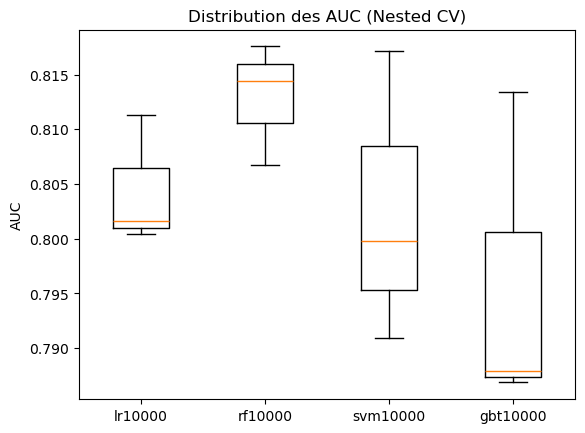

[0.8015740740740699, 0.8003861744741054, 0.8113205511288202]
[0.8143926411290335, 0.8067528100494942, 0.8175697211155383]
[0.7908761760752776, 0.799743607802357, 0.8171364541832745]
[0.8133988575268816, 0.7868520702433702, 0.7878627158034526]


In [55]:
visualisation_AUC_nestedCV({
    "lr": lr_scores,
    "rf": rf_scores,
    "svm": svm_scores,
    "gbt": gbt_scores
}, train_df)

# A REPARER

print(lr_scores)
print(rf_scores)
print(svm_scores)
print(gbt_scores)

### 1.9.2 Evaluation du modèle sur un jeu de données test

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, roc_curve, auc,
    accuracy_score, precision_score, recall_score, f1_score
)
import pandas as pd

def test_models(models, model_names=None, test_df=None):
    """
    Évalue n modèles Spark sur test_df et retourne un DataFrame de métriques.
    model_names est optionnel.
    """
    if model_names is not None and len(models) != len(model_names):
        raise ValueError(
            f"Nombre de modèles ({len(models)}) différent du nombre de noms ({len(model_names)})"
        )
    
    # Si aucun nom fourni → utiliser le nom de classe Spark
    if model_names is None:
        model_names = [m.__class__.__name__ for m in models]

    results = []

    for model, name in zip(models, model_names):
        print(f"\n=== Évaluation du modèle : {name} ===")
        
        preds = model.transform(test_df)

        cols = ["label", "prediction"]
        has_prob = "probability" in preds.columns
        
        if has_prob:
            cols.append("probability")
        else:
            cols.append("rawPrediction")

        pdf = preds.select(*cols).toPandas()

        y_true = pdf["label"].astype(int)
        y_pred = pdf["prediction"].astype(int)

        if has_prob:
            y_score = pdf["probability"].apply(lambda x: float(x[1]))
        else:
            y_score = pdf["rawPrediction"].apply(lambda x: float(x[1]))

        # Métriques
        acc = accuracy_score(y_true, y_pred)
        prec = precision_score(y_true, y_pred, zero_division=0)
        rec = recall_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)

        fpr, tpr, _ = roc_curve(y_true, y_score)
        roc_auc = auc(fpr, tpr)

        results.append({
            "model": name,
            "accuracy": acc,
            "precision": prec,
            "recall": rec,
            "f1_score": f1,
            "roc_auc": roc_auc
        })
        # Graphiques
        plt.figure(figsize=(5,4))
        plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
        plt.plot([0, 1], [0, 1], linestyle="--")
        plt.title(f"ROC - {name}")
        plt.xlabel("FPR")
        plt.ylabel("TPR")
        plt.legend()
        plt.show()

        cm = confusion_matrix(y_true, y_pred)
        plt.figure(figsize=(4,4))
        sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
        plt.title(f"Matrice de confusion - {name}")
        plt.xlabel("Prédiction")
        plt.ylabel("Réel")
        plt.show()

    return pd.DataFrame(results)


=== Évaluation du modèle : LogReg ===


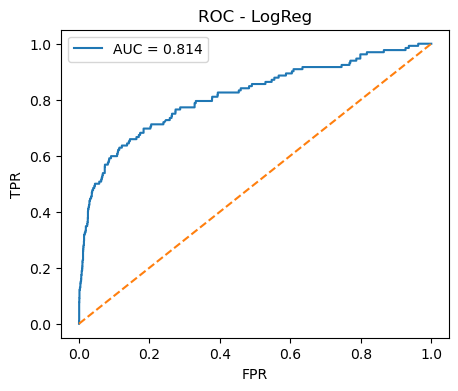

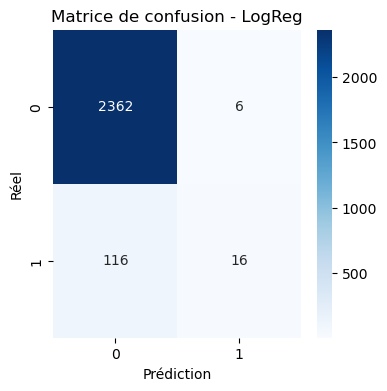


=== Évaluation du modèle : RandomForest ===


25/12/04 20:36:31 WARN DAGScheduler: Broadcasting large task binary with size 1070.1 KiB
                                                                                

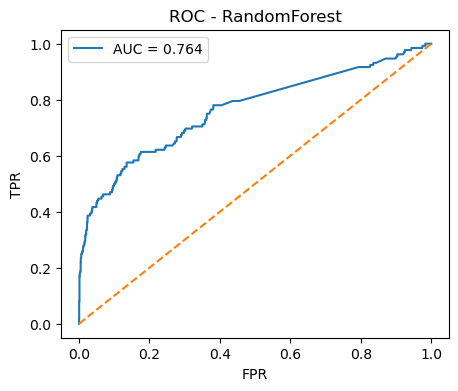

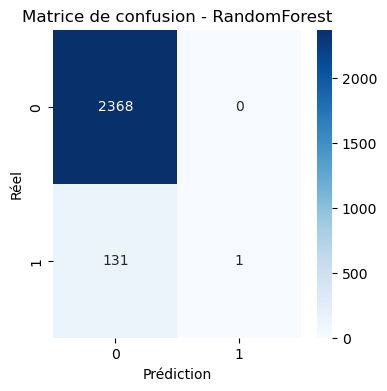


=== Évaluation du modèle : LinearSVM ===


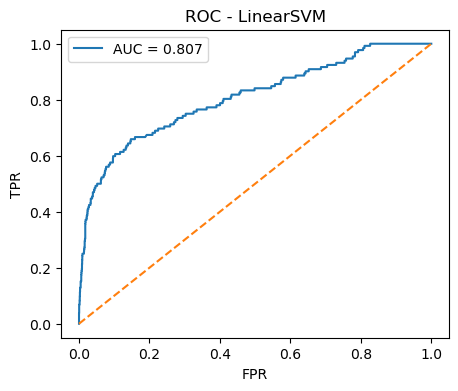

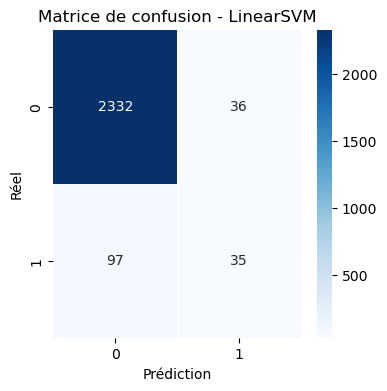


=== Évaluation du modèle : GBT ===


ERROR:root:KeyboardInterrupt while sending command.                 (0 + 2) / 2]
Traceback (most recent call last):
  File "/opt/spark/python/lib/py4j-0.10.9.9-src.zip/py4j/java_gateway.py", line 1038, in send_command
    response = connection.send_command(command)
  File "/opt/spark/python/lib/py4j-0.10.9.9-src.zip/py4j/clientserver.py", line 535, in send_command
    answer = smart_decode(self.stream.readline()[:-1])
                          ~~~~~~~~~~~~~~~~~~~~^^
  File "/home/vboxuser/ENTER/lib/python3.13/socket.py", line 719, in readinto
    return self._sock.recv_into(b)
           ~~~~~~~~~~~~~~~~~~~~^^^
KeyboardInterrupt
ERROR:py4j.clientserver:Exception occurred while shutting down connection
Traceback (most recent call last):
  File "/opt/spark/python/lib/py4j-0.10.9.9-src.zip/py4j/java_gateway.py", line 1038, in send_command
    response = connection.send_command(command)
  File "/opt/spark/python/lib/py4j-0.10.9.9-src.zip/py4j/clientserver.py", line 535, in send_command
   

KeyboardInterrupt: 

In [57]:
models = [best_lr, best_rf, best_svm, best_gbt]
model_names = ["LogReg", "RandomForest", "LinearSVM", "GBT"]

metrics_df = test_models(models, model_names, test_df)

In [ ]:
print(metrics_df)

Les accuracies sont toutes très proches (entre 0.946 et 0.953). Cela indique :
- L’accuracy n’est pas un bon indicateur ici : un modèle qui prédit presque toujours la classe majoritaire peut avoir une excellente accuracy (étant donné le fort déséquilibre des classes)
- On s’appuie donc principalement sur recall, precision, f1 et AUC.

**LogReg**
- Très peu de positifs détectés (recall très bas).
- Quand elle prédit positif, elle a plutôt raison (precision élevée).
- Modèle conservateur, prédictions positives rares.
- AUC très bonne : le modèle sépare bien les classes, mais le seuil 0.5 n’est pas optimal.
  
Conclusion : bon potentiel, mais nécessite optimisation du seuil ou ajustement des poids de classes.

**RandomForest**
- Le modèle ne détecte quasiment aucun positif.
- Précision parfaite uniquement parce qu'il a dû prédire très peu de positifs.
- Typique d'un modèle qui s’effondre sur la classe minoritaire.
- AUC correcte, mais inutilisable en l’état.

Conclusion : modélisation trop biaisée vers la classe majoritaire. Nécessite rebalancing, tuning ou modification du seuil.

**LinearSVM** 

- Le meilleur compromis recall/precision.
- Détecte plus de positifs que les autres.
- F1 le plus élevé → meilleur modèle opérationnel pour identifier les positifs.
- AUC très bonne, proche de LogReg.

Conclusion : modèle le plus équilibré. Performant malgré l’absence de probas natives.

**GBT**

- Le meilleur compromis recall/precision.
- Détecte plus de positifs que les autres.
- F1 le plus élevé → meilleur modèle opérationnel pour identifier les positifs.
- AUC très bonne, proche de LogReg.

Conclusion : modèle le plus équilibré. Performant malgré l’absence de probas natives.

**Conclusion générale**

- Le déséquilibre des classes est le problème principal. 
- Nécessité d'ajuster le seuil --> regarder la courbe ROC
- Les modèles maximisent naturellement l'accuracy au détriment de la classe minoritaire --> changer la métrique à maximiser
- **LinearSVM et GBT sont les modèles les plus prometteurs.**
- **LogReg a un fort potentiel si l’on ajuste le seuil ou pondère les classes.**
- **RandomForest est inutilisable tant que le déséquilibre n’est pas traité.**

### 1.9.3 Pistes d'amélioration

Plusieurs pistes d'améliorations : 

- On peut améliorer les données qu'on donne au modèle :
    - Feature engineering (longueur des textes, nb de mentions, nb de mots offensants connus…)
    - faire des n-grams
- S'attaquer au déséquilibre des classes
    - Rééchantillonage : oversampling des positifs (SMOTE, RandomOverSampler), undersampling des négatifs
    - Weights : classWeightCol ou pondération des observations dans le loss.
    - Changer les seuils : ajuster le threshold de décision pour maximiser F1 ou PR-AUC
    - Changer la fonction coût : focal loss, weighted cross-entropy
    - Changer la métrique à maximiser 
- Utiliser des modèles plus adaptés / MLP, CNN
- Donner toutes les colonnes au modèle : pour apprendre des tâches auxiliaires pendant l’entraînement :
      - prédire si un commentaire mentionne une identité
      - la sortie de ce modèle peut être utilisée comme feature dérivée pour le modèle principale
      - = multi-task learning ou feature augmentation via tâches auxiliaires
- Autres pistes :
    - Cross-validation stratifiée
    - Augmentation de texte : synonymes, paraphrases, back-translation pour enrichir la classe minoritaire
    - **Word Embeddings (Word2Vec ou GloVe)**

# 2. Amélioration des performances

## 2.1 Feature engineering

### 2.1.1 Création des bigrams

In [58]:
from pyspark.ml.feature import NGram

def add_bigrams(df, n=2, input_col="tokens", output_col="bigrams"):

    ngram = NGram(n=n, inputCol=input_col, outputCol=output_col)
    return ngram.transform(df)
    
train_df = add_bigrams(train_df)
train_df.select("tokens", "bigrams").show(5, truncate=50)

[Stage 128:>                                                        (0 + 1) / 1]

+--------------------------------------------------+--------------------------------------------------+
|                                            tokens|                                           bigrams|
+--------------------------------------------------+--------------------------------------------------+
|[south, hill, need, new, season, market, portla...|[south hill, hill need, need new, new season, s...|
|[murder, without, due, process, thats, way, gar...|[murder without, without due, due process, proc...|
|          [must, laughing, stock, world, actually]|[must laughing, laughing stock, stock world, wo...|
|                                  [wish, upon, st]|                              [wish upon, upon st]|
|                                   [buy, umbrella]|                                    [buy umbrella]|
+--------------------------------------------------+--------------------------------------------------+
only showing top 5 rows


In [ ]:
test_df = add_bigrams(test_df)

In [ ]:
train_df.printSchema()

### 2.1.2 Ajout de features basées sur comments

In [59]:
from pyspark.sql.functions import col, length, size, split, regexp_replace, lower, udf, round
from pyspark.sql.types import IntegerType
import re

def extract_text_features(df, stopwords_list=None):
    """
    Ajoute des features textuelles et numériques à partir de la colonne 'comment_text'.
    
    Args:
        df: DataFrame Spark avec une colonne 'comment_text'.
        stopwords_list: liste de stopwords à utiliser pour le comptage.
        
    Returns:
        DataFrame avec les nouvelles features.
    """
    
    if stopwords_list is None:
        stopwords_list = ["the", "and", "is", "in", "it", "of", "to", "a"]
    
    df_features = df
    
    # --- Longueur et structure ---
    df_features = df_features.withColumn("char_count", length(col("comment_text")))
    df_features = df_features.withColumn("word_count", size(split(col("comment_text"), r"\s+")))
    df_features = df_features.withColumn("sentence_count", size(split(col("comment_text"), r"[.!?]+")))
    
    # --- Ponctuation ---
    df_features = df_features.withColumn("exclamation_count", size(split(col("comment_text"), "!")))
    df_features = df_features.withColumn("question_count", size(split(col("comment_text"), r"\?")))
    
    # --- Majuscules consécutives ---
    def count_consec_caps(text):
        return len(re.findall(r"[A-Z]{2,}", text))
    count_consec_caps_udf = udf(count_consec_caps, IntegerType())
    df_features = df_features.withColumn("consec_caps_count", count_consec_caps_udf(col("comment_text")))
    
    # --- Majuscules / minuscules ---
    df_features = df_features.withColumn("uppercase_count", size(split(regexp_replace(col("comment_text"), r"[^A-Z]", ""), "")))
    df_features = df_features.withColumn("lowercase_count", size(split(regexp_replace(col("comment_text"), r"[^a-z]", ""), "")))
    df_features = df_features.withColumn("ratio_upper_lower", col("uppercase_count") / (col("lowercase_count") + 1))
    
    # --- Mots uniques / ratio ---
    df_features = df_features.withColumn("unique_word_count", size(split(regexp_replace(lower(col("comment_text")), r"[^\w\s]", ""), " ")))
    df_features = df_features.withColumn("unique_ratio", col("unique_word_count") / (col("word_count") + 1))
    
    # --- Stopwords ---
    def count_stopwords(text):
        words = re.findall(r"\b\w+\b", text.lower())
        return sum([1 for w in words if w in stopwords_list])
    count_stopwords_udf = udf(count_stopwords, IntegerType())
    df_features = df_features.withColumn("stopword_count", count_stopwords_udf(col("comment_text")))
    
    # --- Mots longs (>6 lettres) ---
    def count_long_words(text):
        words = re.findall(r"\b\w+\b", text)
        return len([w for w in words if len(w) > 6])
    count_long_words_udf = udf(count_long_words, IntegerType())
    df_features = df_features.withColumn("long_word_count", count_long_words_udf(col("comment_text")))
    df_features = df_features.withColumn("long_word_ratio", col("long_word_count") / (col("word_count") + 1))
    
    # --- Symboles spéciaux ---
    special_chars = ["@", "#", "$", "*"]
    def count_special_chars(text):
        return sum([text.count(c) for c in special_chars])
    count_special_chars_udf = udf(count_special_chars, IntegerType())
    df_features = df_features.withColumn("special_char_count", count_special_chars_udf(col("comment_text")))
    
    # --- Arrondir certaines colonnes float ---
    float_cols = ["ratio_upper_lower", "unique_ratio", "long_word_ratio"]
    for c in float_cols:
        df_features = df_features.withColumn(c, round(col(c), 3))
    
    # --- Sélection finale des colonnes ---
    final_columns = [
        "id", "char_count", "word_count", "sentence_count", "exclamation_count",
        "question_count", "consec_caps_count", "uppercase_count", "lowercase_count",
        "ratio_upper_lower", "unique_word_count", "unique_ratio", "stopword_count",
        "long_word_count", "long_word_ratio", "special_char_count"
    ]
    
    # return df_features.select(final_columns)
    return df_features

df_new_features = extract_text_features(train_tronq)

### 2.1.3 Jointure sur l'ID

In [ ]:
df_train_feat_eng = df_new_features.join(train_df, on="id", how="inner")
df_test_feat_eng = df_new_features.join(test_df, on="id", how="inner")

print(df_test_feat_eng.count())
df_test_feat_eng.columns

In [ ]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import (
    StringIndexer, CountVectorizer, IDF,
    VectorAssembler, StandardScaler
)

def build_pipeline_part2(model, combinaison):

    # 1. TF-IDF tokens
    token_cv = CountVectorizer(
        inputCol="tokens",
        outputCol="tokens_tf",
        minDF=5
    )
    token_idf = IDF(
        inputCol="tokens_tf",
        outputCol="tokens_tfidf"
    )

    # 2. TF-IDF bigrams
    bigram_cv = CountVectorizer(
        inputCol="bigrams",
        outputCol="bigrams_tf",
        minDF=5
    )
    bigram_idf = IDF(
        inputCol="bigrams_tf",
        outputCol="bigrams_tfidf"
    )

    # --------------------------------------------------
    # New Features : vectorisation + normalisation
    # --------------------------------------------------

    # 3. Features numériques
    numeric_features = [
        "char_count",
        "word_count",
        "sentence_count",
        "exclamation_count",
        "question_count",
        "consec_caps_count",
        "uppercase_count",
        "lowercase_count",
        "ratio_upper_lower",
        "unique_word_count",
        "unique_ratio",
        "stopword_count",
        "long_word_count",
        "long_word_ratio",
        "special_char_count"
    ]

    # -------------------------
    # 1. w2v + numeric features
    # -------------------------
    
    assembler_w2v = VectorAssembler(
        inputCols = numeric_features + w2v_features,
        outputCol = "w2v_raw"
    )
    
    scaler_w2v = StandardScaler(
        inputCol = "w2v_raw",
        outputCol = "w2v_scaled"
    )
    
    assembler_w2v_target = VectorAssembler(
        inputCols = ["w2v_scaled", "target", "label"],
        outputCol = "w2v_all"
    )

    # -------------------------
    # 2. tf-idf + numeric features
    # -------------------------
    
    assembler_tfidf = VectorAssembler(
        inputCols = numeric_features + ["tokens_tfidf", "bigrams_tfidf"],
        outputCol = "tfidf_raw"
    )
    
    scaler_tfidf = StandardScaler(
        inputCol = "tfidf_raw",
        outputCol = "tfidf_scaled"
    )
    
    assembler_tfidf_target = VectorAssembler(
        inputCols = ["tfidf_scaled", "target", "label"],
        outputCol = "tfidf_all"
    )

    # -------------------------
    # 3. w2v + tf-idf
    # -------------------------
    
    assembler_w2v_tfidf = VectorAssembler(
        inputCols = ["w2v_scaled", "tfidf_scaled"],
        outputCol = "w2v_tfidf_raw"
    )
    
    scaler_w2v_tfidf = StandardScaler(
        inputCol = "w2v_tfidf_raw",
        outputCol = "w2v_tfidf_scaled"
    )
    
    assembler_w2v_tfidf_target = VectorAssembler(
        inputCols = ["w2v_tfidf_scaled", "target", "label"],
        outputCol = "w2v_tfidf_all"
    )

    # -------------------------
    # 4. Assemblage global 
    # -------------------------

    assembler_global = VectorAssembler(
    inputCols=[
        "w2v_scaled",
        "tfidf_scaled",
        "w2v_tfidf_scaled",
        "target",
        "label"
    ],
    outputCol="features_final"
)

    # target et label ne sont pas ajoutés 3 fois ici, en fait je construits plusieurs pipeline à retourner en fonction du paramètre combinaison en paramètre
    
    # 8. Modèle fourni par l'utilisateur
    model.setParams(
        featuresCol="features",
        labelCol="label"
    )
    

    # ---------------------------------------------------------
    # Switch selon la combinaison
    # ---------------------------------------------------------

    if combinaison == "w2v":
        pipeline = Pipeline(stages=[
            assembler_w2v,
            scaler_w2v,
            assembler_w2v_target,   # contient w2v_scaled + target + label
            model
        ])

    elif combinaison == "tfidf":
        pipeline = Pipeline(stages=[
            token_cv, token_idf,
            bigram_cv, bigram_idf,
            assembler_tfidf,
            scaler_tfidf,
            assembler_tfidf_target,  # contient tfidf_scaled + target + label
            model
        ])

    elif combinaison == "w2v+tfidf":
        pipeline = Pipeline(stages=[
            token_cv, token_idf,
            bigram_cv, bigram_idf,
            assembler_w2v, scaler_w2v,
            assembler_tfidf, scaler_tfidf,
            assembler_w2v_tfidf,
            scaler_w2v_tfidf,
            assembler_w2v_tfidf_target,  # contient w2v_tfidf_scaled + target + label
            model
        ])

    elif combinaison == "global":
        pipeline = Pipeline(stages=[
            token_cv, token_idf,
            bigram_cv, bigram_idf,
            assembler_w2v, scaler_w2v,
            assembler_tfidf, scaler_tfidf,
            assembler_w2v_tfidf, scaler_w2v_tfidf,
            assembler_global,  # mélange w2v_scaled, tfidf_scaled, w2v_tfidf_scaled + target + label
            model
        ])

    else:
        raise ValueError(f"Combinaison inconnue : {combinaison}")

    return pipeline

In [ ]:
model_name_feat_eng, best_lr_feat_eng, best_lr_params_feat_eng, lr_scores_feat_eng = train_or_load_nested_model(lr, lr_grid, df_train_feat_eng, df_train_feat_eng.count(), LOAD_MODEL, SAVE_MODEL,"feat_eng",training_func=simple_cross_validator)

In [ ]:
model_name_rf_feat_eng, best_rf_feat_eng, best_rf_params_feat_eng, rf_scores_feat_eng = train_or_load_nested_model(
    rf, 
    rf_grid, 
    df_train_feat_eng, 
    df_train_feat_eng.count(), 
    LOAD_MODEL, 
    SAVE_MODEL,
    "feat_eng",
    training_func=simple_cross_validator
)

In [ ]:
model_name_svm_feat_eng, best_svm_feat_eng, best_svm_params_feat_eng, svm_scores_feat_eng = train_or_load_nested_model(
    svm, 
    svm_grid, 
    df_train_feat_eng, 
    df_train_feat_eng.count(), 
    LOAD_MODEL, 
    SAVE_MODEL,
    "feat_eng",
    training_func=simple_cross_validator
)

In [ ]:
# model_name_gbt_feat_eng, best_gbt_feat_eng, best_gbt_params_feat_eng, gbt_scores_feat_eng = train_or_load_nested_model(
#     gbt, 
#     gbt_grid, 
#     df_train_feat_eng, 
#     df_train_feat_eng.count(), 
#     LOAD_MODEL, 
#     SAVE_MODEL,
#     "feat_eng",
#     training_func=simple_cross_validator
# )

## 2.2 Word embedding

### 2.2.1 Entrainement du modèle Word2Vec
On enlève les stopwords pour pouvoir utiliser une fenetre plus petite et on garde la lemmatisation pour réduire le nombre de paramètres

In [60]:
from pyspark.ml.feature import Word2Vec

nothing, large_corpus_df = preprocess(train, limit=None)

corpus_size = large_corpus_df.count()
print(f"Taille du corpus : {corpus_size} lignes")

# http://localhost:4040/jobs/ pour voir les jobs

word2Vec = Word2Vec(
    vectorSize=100,      # dimension de votre vecteur de sortie, + grand = représente mieux les données ; 
    minCount=5,          # Ignore les mots très rares (bruit)
    inputCol="tokens",   # Filtre de fréquence
    outputCol="w2v_features", 
    maxIter=10,          # nombres d'epochs
    windowSize=5,        # taille de la fenêtre de contexte
    stepSize=0.025       # Learning rate standard
)

model_name = f"word2Vec_{corpus_size}"

if LOAD_MODEL and os.path.exists(os.path.join(BASE_MODEL_PATH, model_name)):
    w2v_model = load_model(model_name, model_type="word2vec")
    print(f"Modèle chargé : {model_name}")
    
else:    
    print(f"Entrainement du modèle : {model_name}")
    w2v_model = word2Vec.fit(large_corpus_df)
    print("Entrainement OK") 

if SAVE_MODEL: 
    save_model(w2v_model, model_name)

Taille du corpus : 1804874 lignes


Modèle word2vec chargé depuis : models/word2Vec_1804874
Modèle chargé : word2Vec_1804874


Comme suggéré lors de notre présentation, il est judicieux d'utiliser un Word2Vec déjà entraîné sur un jeu de données plus large afin de réduire l'overfitting et d'augmenter la qualité de la vectorisation

In [ ]:
# Vérification sémantique : quels mots sont proches de "stupid" ou "gay" ?
try:
    print("Mots proches de 'black' :")
    w2v_model.findSynonyms("black", 5).show()
    
    print("Mots proches de 'stupid' :")
    w2v_model.findSynonyms("stupid", 5).show()
except Exception as e:
    print("Le mot demandé n'est pas dans le vocabulaire (filtré par minCount).")

In [ ]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import pandas as pd
import numpy as np

# 1. Récupération des vecteurs du modèle Spark
# getVectors() retourne un DataFrame Spark avec col "word" et col "vector"
vectors_df = w2v_model.getVectors()

# 2. On prend un échantillon pour la lisibilité (ex: les 300 premiers mots)
# Sinon le graphique sera illisible avec des milliers de mots superposés
vocab_sample = vectors_df.limit(300).toPandas()

# 3. Préparation des données pour t-SNE
# La colonne 'vector' contient des DenseVector, on doit les transformer en liste numpy
X = np.array(vocab_sample["vector"].tolist())
words = vocab_sample["word"].tolist()

# 4. Réduction de dimension (100D -> 2D)
print("Calcul du t-SNE en cours...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30, init='pca', learning_rate='auto')
X_embedded = tsne.fit_transform(X)

# 5. Création du graphique
plt.figure(figsize=(16, 10))
plt.scatter(X_embedded[:, 0], X_embedded[:, 1], alpha=0.5)

# Ajouter les étiquettes (les mots) sur les points
for i, word in enumerate(words):
    plt.annotate(word, xy=(X_embedded[i, 0], X_embedded[i, 1]), fontsize=9)

plt.title("Visualisation t-SNE des Word Embeddings (Top 300 mots)")
plt.grid(True)
plt.show()

### TESTS

In [ ]:
print("Transformation...")
df_final_w2v = w2v_model.transform(df_train_feat_eng)
df_final_test = w2v_model.transform(df_test_feat_eng)

print("Transformation terminée.")

df_final_w2v.select("id", "tokens", "bigrams", "word_count", "w2v_features").show(5)

In [ ]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import CountVectorizer, IDF, VectorAssembler, StandardScaler

def build_pipeline_part2(model, combinaison, debug=True):
    """
    Construit un pipeline dynamique et affiche sa structure pour le débogage.
    
    Args:
        model: L'instance du modèle (ex: LogisticRegression)
        combinaison (str): "num", "w2v", "tfidf", "w2v+tfidf", "all"...
        debug (bool): Si True, affiche les étapes du pipeline dans la console.
    """
    
    combinaison = combinaison.lower()
    stages = []
    final_assembler_inputs = []

    # ====================================================
    # 1. DÉFINITION DES BLOCS DE FEATURES
    # ====================================================

    # --- A. FEATURES NUMÉRIQUES ---
    numeric_features = [
        "char_count", "word_count", "sentence_count", "exclamation_count", 
        "question_count", "consec_caps_count", "uppercase_count", 
        "lowercase_count", "ratio_upper_lower", "unique_word_count", 
        "unique_ratio", "stopword_count", "long_word_count", 
        "long_word_ratio", "special_char_count"
    ]
    
    if "num" in combinaison or "all" in combinaison:
        assembler_num = VectorAssembler(inputCols=numeric_features, outputCol="vec_num_raw")
        scaler_num = StandardScaler(inputCol="vec_num_raw", outputCol="vec_num_scaled", 
                                    withStd=True, withMean=True)
        stages.extend([assembler_num, scaler_num])
        final_assembler_inputs.append("vec_num_scaled")

    # --- B. FEATURES TF-IDF ---
    if "tfidf" in combinaison or "all" in combinaison:
        token_cv = CountVectorizer(inputCol="tokens", outputCol="tf_tokens", minDF=5)
        token_idf = IDF(inputCol="tf_tokens", outputCol="tfidf_tokens")
        
        bigram_cv = CountVectorizer(inputCol="bigrams", outputCol="tf_bigrams", minDF=5)
        bigram_idf = IDF(inputCol="tf_bigrams", outputCol="tfidf_bigrams")
        
        assembler_tfidf = VectorAssembler(inputCols=["tfidf_tokens", "tfidf_bigrams"], 
                                          outputCol="vec_tfidf_raw")
        
        # withMean=False pour éviter OOM sur les vecteurs sparse
        scaler_tfidf = StandardScaler(inputCol="vec_tfidf_raw", outputCol="vec_tfidf_scaled", 
                                      withStd=True, withMean=False)
        
        stages.extend([token_cv, token_idf, bigram_cv, bigram_idf, assembler_tfidf, scaler_tfidf])
        final_assembler_inputs.append("vec_tfidf_scaled")

    # --- C. FEATURES WORD2VEC ---
    if "w2v" in combinaison or "all" in combinaison:
        # On suppose w2v_features déjà présent
        final_assembler_inputs.append("w2v_features")

    # ====================================================
    # 2. ASSEMBLAGE FINAL
    # ====================================================
    
    if not final_assembler_inputs:
        raise ValueError(f"Aucune feature sélectionnée pour la combinaison : {combinaison}")

    assembler_final = VectorAssembler(inputCols=final_assembler_inputs, outputCol="features_final")
    stages.append(assembler_final)

    # ====================================================
    # 3. MODÈLE
    # ====================================================
    
    model.setParams(featuresCol="features_final", labelCol="label")
    stages.append(model)

    # ====================================================
    # 4. DEBUG PRINTING (NOUVEAU BLOC)
    # ====================================================
    if debug:
        print(f"\n{'='*60}")
        print(f"🔍 DEBUG PIPELINE - Combinaison : '{combinaison}'")
        print(f"{'='*60}")
        
        for i, stage in enumerate(stages):
            stage_name = stage.__class__.__name__
            params = ""
            
            # Récupération intelligente des entrées/sorties pour l'affichage
            if hasattr(stage, "getInputCol"):
                params += f"In: {stage.getInputCol()} "
            elif hasattr(stage, "getInputCols"):
                # On tronque si la liste est trop longue pour la lisibilité
                cols = stage.getInputCols()
                cols_str = str(cols) if len(cols) < 5 else f"[{cols[0]}, ..., {cols[-1]}] ({len(cols)} cols)"
                params += f"In: {cols_str} "
            elif hasattr(stage, "getFeaturesCol"): # Pour le modèle final
                params += f"Features: {stage.getFeaturesCol()} | Label: {stage.getLabelCol()}"

            if hasattr(stage, "getOutputCol"):
                params += f"-> Out: {stage.getOutputCol()}"
                
            print(f"Step {i+1:02d} : {stage_name:<20} | {params}")
        print(f"{'='*60}\n")

    return Pipeline(stages=stages)

In [ ]:
# Liste de toutes les combinaisons
combinaisons = ["num", "w2v", "tfidf", "w2v+tfidf", "w2v+num", "tfidf+num", "all"]

# Dictionnaires pour stocker les résultats
models_name_lr = {}
best_lrs = {}
best_lr_params = {}
lr_scores = {}

for combinaison in combinaisons:
    # Générer des noms dynamiques pour chaque combinaison
    model_name = f"model_name_lr_{combinaison}"
    best_model_name = f"best_lr_{combinaison}"
    params_name = f"best_lr_params_{combinaison}"
    scores_name = f"lr_scores_{combinaison}"

    # Appel de la fonction train_or_load_nested_model
    model, best_model, best_params, scores = train_or_load_nested_model(
        lr,                     # modèle initial
        lr_grid,                # grille de paramètres
        df_final_w2v,           # dataframe
        df_final_w2v.count(), 
        LOAD_MODEL,
        SAVE_MODEL,
        f"final_preprocess_{combinaison}",
        training_func=simple_cross_validator,
        combinaison=combinaison,
        k_folds=1
    )

    # Stocker les résultats dans les dictionnaires
    models_name_lr[combinaison] = model
    best_lrs[combinaison] = best_model
    best_lr_params[combinaison] = best_params
    lr_scores[combinaison] = scores

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score
import pandas as pd
from pyspark.ml.evaluation import BinaryClassificationEvaluator

def evaluate_models_on_test_set(
    best_lrs: dict, 
    test_df,
    plot_cm: bool = True
) -> dict:
    """
    Évalue les modèles en se concentrant sur la classe minoritaire (1 = Toxique).
    """
    final_test_scores = {}
    
    # Evaluateur Spark uniquement pour l'AUC (qui a besoin des probabilités brutes)
    binary_evaluator = BinaryClassificationEvaluator(
        labelCol="label", rawPredictionCol="rawPrediction", metricName="areaUnderROC"
    )

    print("Démarrage de l'évaluation CIBLÉE (Classe 1 - Toxique)...")

        # Normalisation de l'entrée : s'assurer que nous itérons toujours sur une liste de tuples (nom, modèle)
    if isinstance(best_lrs, dict):
        # Cas 1 : Dictionnaire (plusieurs modèles)
        models_to_iterate = best_lrs.items()
    elif best_lrs is not None:
        # Cas 2 : Un seul modèle (on l'encapsule avec un nom générique)
        models_to_iterate = [("modele_unique", best_lrs)]
    else:
        # Cas 3 : L'entrée est vide/None
        models_to_iterate = []
    
    
    for combinaison, model_pipeline in models_to_iterate:
        print(f"\n{'='*40}")
        print(f"--- Modèle : {combinaison} ---")
        
        try:
            # 1. Prédictions Spark
            predictions = model_pipeline.transform(test_df)
            
            # 2. Calcul de l'AUC via Spark (toujours fiable)
            auc = binary_evaluator.evaluate(predictions)
            
            # 3. Conversion en Pandas pour les métriques précises de la classe 1
            # On ne récupère que les colonnes nécessaires pour économiser la RAM
            y_preds_pdf = predictions.select("label", "prediction").toPandas()
            
            y_true = y_preds_pdf["label"]
            y_pred = y_preds_pdf["prediction"]
            
            # --- C'EST ICI QUE TOUT CHANGE ---
            # pos_label=1 force le calcul UNIQUEMENT sur la classe toxique
            prec_1 = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
            rec_1 = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
            f1_1 = f1_score(y_true, y_pred, pos_label=1, zero_division=0)
            acc = accuracy_score(y_true, y_pred) # L'accuracy reste globale
            
            # Stockage avec des noms explicites
            final_test_scores[combinaison] = {
                "AUC": auc,
                "F1_Toxic": f1_1,       # F1 sur la classe 1
                "Recall_Toxic": rec_1,  # Vrai taux de détection des toxiques
                "Precision_Toxic": prec_1,
                "Accuracy_Global": acc
            }
            
            print(f"TOXIC CLASS -> Recall: {rec_1:.4f} | Precision: {prec_1:.4f} | F1: {f1_1:.4f}")
            print(f"   Global AUC: {auc:.4f}")

            # 4. Matrice de Confusion
            if plot_cm:
                cm = confusion_matrix(y_true, y_pred)
                plt.figure(figsize=(4, 3))
                sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', cbar=False,
                            xticklabels=['Sain (0)', 'Toxique (1)'],
                            yticklabels=['Sain (0)', 'Toxique (1)'])
                plt.xlabel('Prédiction')
                plt.ylabel('Réel')
                plt.title(f'Confusion Matrix - {combinaison}')
                plt.show()

        except Exception as e:
            print(f"ERREUR pour {combinaison}: {e}")
            final_test_scores[combinaison] = {"AUC": 0.0}

    print("\nÉvaluation terminée.")
    return final_test_scores

import sys
sys.tracebacklimit = 0


# Appel de la fonction
test_results = evaluate_models_on_test_set(best_lrs, df_final_test, plot_cm=True)

# Création du tableau récapitulatif (votre code existant)
df_test_results = pd.DataFrame.from_dict(test_results, orient='index')
df_test_results.reset_index(inplace=True)
df_test_results.rename(columns={'index': 'Combinaison'}, inplace=True)

# Affichage du tableau final coloré
print("\n>>> RÉCAPITULATIF DES SCORES")
display(df_test_results.style.background_gradient(cmap='Greens', subset=df_test_results.columns[1:]))

del sys.tracebacklimit

In [ ]:
# import pandas as pd
# import seaborn as sns
# import matplotlib.pyplot as plt

# # 1. Conversion du dictionnaire lr_scores en DataFrame
# # orient='index' utilise les clés (num, w2v...) comme index de lignes
# df_results = pd.DataFrame.from_dict(lr_scores, orient='index')

# # On remet l'index (les noms des combinaisons) en colonne
# df_results.reset_index(inplace=True)
# df_results.rename(columns={'index': 'Combinaison'}, inplace=True)
# df_results.rename(columns={0: 'AUC'}, inplace=True)

# # -------------------------------------------------------
# # 2. Le Tableau (Styled)
# # -------------------------------------------------------
# print("\n>>> TABLEAU COMPARATIF DES PERFORMANCES PENDANT LE TRAINING")

# # On sélectionne les colonnes numériques pour le gradient de couleur
# numeric_cols = df_results.select_dtypes(include=['float', 'int']).columns

# styled_table = df_results.style.background_gradient(cmap='Greens', subset=numeric_cols)\
#     .format(precision=3)\
#     .set_caption("Résultats par Combinaison de Features")\
#     .set_properties(**{'text-align': 'center'})

# display(styled_table)

# # Affichage du tableau final
# print("\n>>> RÉSULTATS FINAUX SUR LE JEU DE TEST")
# styled_final_table = df_test_results.style.background_gradient(cmap='Blues', subset=df_test_results.columns[1:])\
#     .format(precision=4)\
#     .set_caption("Performance Finale sur le Jeu de Test (LogReg)")\
#     .set_properties(**{'text-align': 'center'})

# display(styled_final_table)

import pandas as pd
from typing import Dict, Any

def display_comparison_tables(
    lr_scores: Dict[str, Any], 
    test_results: Dict[str, Dict[str, float]]
):
    """
    Convertit les dictionnaires de scores (Training CV et Test Final) en DataFrames
    stylisés et les affiche.

    Args:
        lr_scores (dict): Scores de Cross-Validation pendant l'entraînement.
        test_results (dict): Scores finaux sur le jeu de test.
    """
    
    # ====================================================
    # 1. TABLEAU DE PERFORMANCE PENDANT LE TRAINING (CV)
    # ====================================================
    
    # Conversion et nettoyage du DataFrame de Training
    df_results = pd.DataFrame.from_dict(lr_scores, orient='index')
    df_results.reset_index(inplace=True)
    df_results.rename(columns={'index': 'Combinaison'}, inplace=True)
    
    # Renommer la colonne AUC qui est souvent un entier '0'
    if 0 in df_results.columns:
        df_results.rename(columns={0: 'AUC'}, inplace=True)
    
    # Affichage du tableau (Training)
    print("\n>>> TABLEAU COMPARATIF DES PERFORMANCES PENDANT LE TRAINING")
    
    numeric_cols_train = df_results.select_dtypes(include=['float', 'int']).columns
    
    styled_table_train = df_results.style.background_gradient(cmap='Greens', subset=numeric_cols_train)\
        .format(precision=3)\
        .set_caption("Résultats de Cross-Validation (Métrique : AUC)")\
        .set_properties(**{'text-align': 'center'})

    display(styled_table_train)

    # ====================================================
    # 2. TABLEAU DE PERFORMANCE FINALE (TEST SET)
    # ====================================================

    # Conversion du DataFrame de Test
    df_test_results = pd.DataFrame.from_dict(test_results, orient='index')
    df_test_results.reset_index(inplace=True)
    df_test_results.rename(columns={'index': 'Combinaison'}, inplace=True)
    
    # Affichage du tableau (Test)
    print("\n>>> RÉSULTATS FINAUX SUR LE JEU DE TEST (Focus Classe 1)")
    
    numeric_cols_test = df_test_results.select_dtypes(include=['float', 'int']).columns
    
    styled_final_table = df_test_results.style.background_gradient(cmap='Blues', subset=numeric_cols_test)\
        .format(precision=4)\
        .set_caption("Performance Finale sur le Jeu de Test (LogReg) - Métriques Ciblées sur la Toxicité (1)")\
        .set_properties(**{'text-align': 'center'})

    display(styled_final_table)

In [ ]:
display_comparison_tables(lr_scores, test_results)

tf+idf ET w2v marche particulièrement bien, en revanche les features obtenues avec le feature engineering ne sont pas très utiles

- w2v très prometteur étant donné que l'entrainement du modèle n'avait été fait que sur 100 000 commentaires
- pour la suite on garde w2v, tfidf, w2v + tfidf, all

**Synthèse**:

**Avant (préprocessing standard, LogReg)**
- Accuracy : 0.9512  
- Precision (toxic=1) : 0.7273  
- Recall (toxic=1) : 0.1212  
- F1 (toxic=1) : 0.2078  
- ROC AUC : 0.8144  

**Après (nouveau pipeline)**
*best model : w2v+tfidf*

- Accuracy : 0.9540  
- Precision (toxic=1) : 0.8148  
- Recall (toxic=1) : 0.1667  
- F1 (toxic=1) : 0.2767  
- ROC AUC : 0.8501

→ Le pipeline w2v+tfidf donne le meilleur rappel, même meilleur que all.
Cela veut dire que tfidf capture mieux les mots rares qui signalent la toxicité, et w2v aide au contexte.

## Pour JB

### Training sur df_final_w2v avec GBT

In [ ]:
# Liste de toutes les combinaisons
combinaisons = ["w2v"]

# Dictionnaires pour stocker les résultats
models_name_gbt = {}
best_gbt = {}
best_gbt_params = {}
gbt_scores = {}

for combinaison in combinaisons:
    # Générer des noms dynamiques pour chaque combinaison
    model_name = f"model_name_gbt_{combinaison}"
    best_model_name = f"best_gbt_{combinaison}"
    params_name = f"best_gbt_params_{combinaison}"
    scores_name = f"gbt_scores_{combinaison}"

    # Appel de la fonction train_or_load_nested_model
    model_gbt, best_model_gbt, best_params_gbt, scores_gbt = train_or_load_nested_model(
        gbt,                     # modèle initial
        gbt_grid,                # grille de paramètres
        df_final_w2v,           # dataframe
        df_final_w2v.count(), 
        LOAD_MODEL,
        SAVE_MODEL,
        f"final_preprocess_{combinaison}",
        training_func=simple_cross_validator,
        combinaison=combinaison,
        k_folds=2
    )

    # Stocker les résultats dans les dictionnaires
    models_name_gbt[combinaison] = model_gbt
    best_gbt[combinaison] = best_model_gbt
    best_gbt_params[combinaison] = best_params_gbt
    gbt_scores[combinaison] = scores_gbt

In [ ]:


# Appel de la fonction
test_results_gbt = evaluate_models_on_test_set(best_gbt, df_final_test, plot_cm=True)

# Création du tableau récapitulatif (votre code existant)
df_test_results_gbt = pd.DataFrame.from_dict(test_results_gbt, orient='index')
df_test_results_gbt.reset_index(inplace=True)
df_test_results_gbt.rename(columns={'index': 'Combinaison'}, inplace=True)

# Affichage du tableau final coloré
print("\n>>> RÉCAPITULATIF DES SCORES")
display(df_test_results_gbt.style.background_gradient(cmap='Greens', subset=df_test_results_gbt.columns[1:]))


In [ ]:
display_comparison_tables(gbt_scores, test_results_gbt)

### Meme chose avec SVM

In [ ]:
# Liste de toutes les combinaisons
combinaisons = ["w2v"]

# Dictionnaires pour stocker les résultats
models_name_svm = {}
best_svm = {}
best_svm_params = {}
svm_scores = {}

for combinaison in combinaisons:
    # Générer des noms dynamiques pour chaque combinaison
    model_name = f"model_name_svm_{combinaison}"
    best_model_name = f"best_svm_{combinaison}"
    params_name = f"best_svm_params_{combinaison}"
    scores_name = f"svm_scores_{combinaison}"

    # Appel de la fonction train_or_load_nested_model
    model_svm, best_model_svm, best_params_svm, scores_svm = train_or_load_nested_model(
        svm,                     # modèle initial
        svm_grid,                # grille de paramètres
        df_final_w2v,           # dataframe
        df_final_w2v.count(), 
        LOAD_MODEL,
        SAVE_MODEL,
        f"final_preprocess_{combinaison}",
        training_func=simple_cross_validator,
        combinaison=combinaison,
        k_folds=2
    )

    # Stocker les résultats dans les dictionnaires
    models_name_svm[combinaison] = model_svm
    best_svm[combinaison] = best_model_svm
    best_svm_params[combinaison] = best_params_svm
    svm_scores[combinaison] = scores_svm

In [ ]:



# Appel de la fonction
test_results_svm = evaluate_models_on_test_set(best_svm, df_final_test, plot_cm=True)

# Création du tableau récapitulatif (votre code existant)
df_test_results_svm = pd.DataFrame.from_dict(test_results_svm, orient='index')
df_test_results_svm.reset_index(inplace=True)
df_test_results_svm.rename(columns={'index': 'Combinaison'}, inplace=True)

# Affichage du tableau final coloré
print("\n>>> RÉCAPITULATIF DES SCORES")
display(df_test_results_svm.style.background_gradient(cmap='Greens', subset=df_test_results_svm.columns[1:]))


In [ ]:
display_comparison_tables(svm_scores, test_results_svm)

## 2.3 Gestion du déséquilibre des classes

In [61]:
def undersample_data(df, ratio_target=1.0):
    """
    Sous-échantillonne la classe majoritaire (0).
    ratio_target : Ratio désiré (Negatifs / Positifs). 1.0 = 50/50.
    """
    pos_df = df.filter(col("label") == 1)
    neg_df = df.filter(col("label") == 0)


    count_pos = pos_df.count()
    count_neg = neg_df.count()
    print(count_pos)
    print(count_neg)
    
    # Quelle fraction des négatifs doit-on garder ?
    fraction = (count_pos * ratio_target) / count_neg
    
    print(f"Undersampling : On garde {fraction:.2%} des données négatives.")
    
    neg_sampled = neg_df.sample(withReplacement=False, fraction=fraction, seed=42)
    
    return pos_df.union(neg_sampled)

### 2.3.1 Ajout d'une fonction lr avec des poids

In [62]:
from pyspark.sql.functions import when

def add_class_weights(df, ratio_multiplier=1):
    """Ajoute une colonne de poids pour équilibrer les classes."""
    
    # 1. Compter les classes
    total = df.count()
    count_pos = df.filter(col("label") == 1).count()
    count_neg = df.filter(col("label") == 0).count()
    
    # 2. Calculer le ratio de balancement
    # Poids pour 0 = 1 (référence)
    # Poids pour 1 = (Nombre Négatifs / Nombre Positifs)
    # Ex: Si 95% neg et 5% pos -> Ratio ~ 19. Un toxique vaut 19 normaux.
    balancing_ratio = (count_neg / count_pos)*ratio_multiplier+1
    print(f"Ratio de déséquilibre : 1 toxique ≈ {balancing_ratio:.2f} commentaires sains.")
    
    # 3. Créer la colonne de poids
    df_weighted = df.withColumn("classWeight", when(col("label") == 1, balancing_ratio).otherwise(1.0))
    
    return df_weighted

### Entrainement

In [ ]:
# Application
train_weighted = add_class_weights(df_final_w2v) # Utilise ton DF d'entraînement final
train_balanced = undersample_data(df_final_w2v, ratio_target=0.5) # ratio 1:1
train_balanced_weighted = add_class_weights(train_balanced) 

# Ré-entraînement du modèle AVEC poids
print("\n🔄 Ré-entraînement avec Class Weights...")
lr_weighted = LogisticRegression(
    featuresCol="features_final", 
    labelCol="label", 
    weightCol="classWeight",  # <--- C'est ici que la magie opère
    maxIter=10
)

model_lr_weighted, best_model_lr_weighted, best_params_lr_weighted, scores_lr_weighted = train_or_load_nested_model(
    lr_weighted,                     # modèle initial
    lr_grid,                # grille de paramètres
    train_weighted,           # dataframe
    train_weighted.count(), 
    LOAD_MODEL,
    SAVE_MODEL,
    f"class_weights_w2v+tfidf",
    training_func=simple_cross_validator,
    combinaison='w2v+tfidf',
    k_folds=2
)

model_lr_balanced, best_model_lr_balanced, best_params_lr_balanced, scores_lr_balanced = train_or_load_nested_model(
    lr,                     # modèle initial
    lr_grid,                # grille de paramètres
    train_balanced,           # dataframe
    train_balanced.count(), 
    LOAD_MODEL,
    SAVE_MODEL,
    f"class_balanced_w2v+tfidf",
    training_func=simple_cross_validator,
    combinaison='w2v+tfidf',
    k_folds=2

)

model_lr_balanced_weighted, best_model_lr_balanced_weighted, best_params_lr_balanced_weighted, scores_lr_balanced_weighted = train_or_load_nested_model(
    lr_weighted,                     # modèle initial
    lr_grid,                # grille de paramètres
    train_balanced_weighted,           # dataframe
    train_balanced_weighted.count(), 
    LOAD_MODEL,
    SAVE_MODEL,
    f"class_weights_w2v+tfidf",
    training_func=simple_cross_validator,
    combinaison='w2v+tfidf',
    k_folds=2
)

In [ ]:

test_results_weights = evaluate_models_on_test_set(best_model_lr_weighted, df_final_test, plot_cm=True)
test_results_balanced = evaluate_models_on_test_set(best_model_lr_balanced, df_final_test, plot_cm=True)
test_results_weights_balanced = evaluate_models_on_test_set(best_model_lr_balanced_weighted, df_final_test, plot_cm=True)

In [ ]:
df_test_results_weights = pd.DataFrame.from_dict(test_results_weights, orient='index')
df_test_results_weights.reset_index(inplace=True)
df_test_results_weights.rename(columns={'index': 'Combinaison'}, inplace=True)

print("\n>>> LR : RÉSULTATS FINAUX SUR LE JEU DE TEST weights")

display(
    df_test_results_weights.style.background_gradient(
        cmap='Blues', 
        subset=df_test_results_weights.columns[1:] # On utilise le DataFrame pour les colonnes
    )
    .format(precision=4)
    .set_caption("Performance Finale sur le Jeu de Test (LogReg) - Avec Poids")
    .set_properties(**{'text-align': 'center'})
)

df_test_results_balanced = pd.DataFrame.from_dict(test_results_balanced, orient='index')
df_test_results_balanced.reset_index(inplace=True)
df_test_results_balanced.rename(columns={'index': 'Combinaison'}, inplace=True)

print("\n>>> LR : RÉSULTATS FINAUX SUR LE JEU DE TEST balanced")

display(
    df_test_results_balanced.style.background_gradient(
        cmap='Blues', 
        subset=df_test_results_balanced.columns[1:] # On utilise le DataFrame pour les colonnes
    )
    .format(precision=4)
    .set_caption("Performance Finale sur le Jeu de Test (LogReg) - Avec Poids")
    .set_properties(**{'text-align': 'center'})
)

df_test_results_weights_balanced = pd.DataFrame.from_dict(test_results_weights_balanced, orient='index')
df_test_results_weights_balanced.reset_index(inplace=True)
df_test_results_weights_balanced.rename(columns={'index': 'Combinaison'}, inplace=True)

print("\n>>> LR : RÉSULTATS FINAUX SUR LE JEU DE TEST weights_balanced")

display(
    df_test_results_weights_balanced.style.background_gradient(
        cmap='Blues', 
        subset=df_test_results_weights_balanced.columns[1:] # On utilise le DataFrame pour les colonnes
    )
    .format(precision=4)
    .set_caption("Performance Finale sur le Jeu de Test (LogReg) - Avec Poids")
    .set_properties(**{'text-align': 'center'})
)

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from pyspark.sql.functions import udf
from pyspark.sql.types import FloatType

import matplotlib.pyplot as plt
import pandas as pd
from pyspark.sql.functions import udf
from pyspark.sql.types import FloatType
from sklearn.metrics import (
    f1_score, recall_score, precision_score, roc_curve, auc, 
    accuracy_score # <--- Ajout de cette métrique
)


def find_best_threshold(model, test_df, model_name):
    """
    Trouve le seuil optimal qui maximise le F1-Score sur la classe Toxique (1)
    et affiche l'AUC et l'Accuracy Générale du modèle.
    """
    # 1. On récupère les prédictions brutes (probabilités)
    predictions = model.transform(test_df)
    
    # On extrait la probabilité de la classe 1 (Toxique)
    extract_prob = udf(lambda x: float(x[1]), FloatType())
    preds_pd = predictions.select("label", extract_prob("probability").alias("score")).toPandas()
    
    y_true = preds_pd["label"]
    y_score = preds_pd["score"]
    
    # Calcul de l'AUC (Area Under ROC - Seuil-Indépendant)
    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)
    
    # 2. On teste plein de seuils entre 0.1 et 0.9
    thresholds = [i/100 for i in range(10, 90, 2)]
    scores = []
    
    for t in thresholds:
        # On applique le seuil manuellement
        y_pred_t = (y_score > t).astype(int)
        
        # On calcule les métriques sur la classe Toxique (1)
        f1 = f1_score(y_true, y_pred_t, pos_label=1, zero_division=0)
        rec = recall_score(y_true, y_pred_t, pos_label=1, zero_division=0)
        prec = precision_score(y_true, y_pred_t, pos_label=1, zero_division=0)
        
        # --- AJOUT DE L'ACCURACY GÉNÉRALE (TOUTES CLASSES) ---
        acc = accuracy_score(y_true, y_pred_t)
        
        scores.append({"threshold": t, "f1": f1, "recall": rec, "precision": prec, "accuracy": acc})
        
    df_scores = pd.DataFrame(scores)
    
    # 3. Trouver le meilleur F1
    best_row = df_scores.loc[df_scores['f1'].idxmax()]
    best_thresh = best_row['threshold']


    # --- AFFICHAGE MIS À JOUR ---
    print(f"==================================================")
    print(f"Analyse de Seuil pour {model_name}")
    print(f"==================================================")
    print(f"AUC (Seuil-Indépendant) : {roc_auc:.4f}")
    print(f"Seuil optimal (Max F1) : {best_thresh}")
    print(f"   -> F1 Toxic (Opt.) : {best_row['f1']:.4f}")
    print(f"   -> Recall Toxic (Opt.) : {best_row['recall']:.4f}")
    print(f"   -> Precision Toxic (Opt.) : {best_row['precision']:.4f}")
    print(f"   -> Accuracy Générale : {best_row['accuracy']:.4f}") # NOUVEAU
    
    # 4. Graphique
    plt.figure(figsize=(10, 6))
    plt.plot(df_scores['threshold'], df_scores['f1'], label='F1 Score', linewidth=3)
    plt.plot(df_scores['threshold'], df_scores['recall'], label='Recall', linestyle='--')
    plt.plot(df_scores['threshold'], df_scores['precision'], label='Precision', linestyle='--')
    plt.axvline(best_thresh, color='red', linestyle=':', label=f'Optimum ({best_thresh})')
    plt.xlabel('Seuil de décision')
    plt.ylabel('Score')
    plt.title(f'Impact du Seuil sur la détection de Toxicité ({model_name})')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    return best_thresh

# Utilisation sur ton meilleur modèle actuel (w2v+tfidf)
# Assure-toi d'utiliser le modèle entraîné (best_lrs['w2v+tfidf'])
optimal_threshold = find_best_threshold(best_lrs['w2v+tfidf'], df_final_test, model_name="best_lrs['w2v+tfidf']")
optimal_threshold = find_best_threshold(best_model_lr_weighted, df_final_test, model_name='best_model_lr_weighted')
optimal_threshold = find_best_threshold(best_model_lr_balanced, df_final_test, model_name='best_model_lr_balanced')
optimal_threshold = find_best_threshold(best_model_lr_balanced_weighted, df_final_test, model_name='best_model_lr_weighted_balanced')

Comme on pouvait s'y attendre on a un meilleur f1 + recall avec ces méthodes mais l'AUC baisse... à voir avec les autres modèles et à pondérer de façon plus douce --> la pondération est assez lourde + on enleve beaucoup du dataset avec balanced.

**Cependant balanced peut s'avérer très intéressant si à la fin on se rend compte qu'on ne pourra jamais faire tourner tout le jeu de donnée car trop gros --> dans ce cas on fait d'une pierre deux coups en faisant un undersampling (on garde moins de données, mais avec une distribution de target moins inégale)**

étant donné les métriques, le meilleur compromis serait un de faire un undersampling avec peu ou pas de pondération. En attendant le meilleur modèle est **RegLog + tfidf + w2c** avec simplement un seuil ajusté à 0.16

In [ ]:
# from pyspark.sql.functions import when, col, udf
# from pyspark.sql.types import FloatType
# from pyspark.ml.classification import LogisticRegression
# from sklearn.metrics import f1_score, recall_score, precision_score, roc_auc_score
# import pandas as pd

# def compute_weight_metrics(
#     base_lr, 
#     train_df, 
#     test_df, 
#     w2v_model,
#     weights_list=[0.05, 0.1, 0.25, 0.5, 0.75, 1.0]
# ):
#     """
#     Entraîne les modèles pour différents poids et retourne les métriques brutes.
#     Aucun affichage graphique ici.
#     """
#     results = []
    
#     # Calcul du ratio de base
#     count_pos = train_df.filter(col("label") == 1).count()
#     count_neg = train_df.filter(col("label") == 0).count()
#     balancing_ratio = count_neg / count_pos
    
#     print(f"🚀 Démarrage des calculs. Ratio de base (1:1) = {balancing_ratio:.2f}")

#     for w_multiplier in weights_list:
#         effective_weight = balancing_ratio * w_multiplier
#         print(f"... Traitement du multiplicateur : {w_multiplier} (Poids: {effective_weight:.2f})")

#         # 1. Colonne de poids
#         weight_col_name = f"weight_{str(w_multiplier).replace('.', '_')}"
#         train_w = train_df.withColumn(weight_col_name, when(col("label") == 1, effective_weight).otherwise(1.0))

#         # 2. Modèle & Pipeline
#         lr_current = base_lr.copy({base_lr.weightCol: weight_col_name})
#         pipeline = build_pipeline_part2(lr_current, "w2v+tfidf", w2v_transformer=w2v_model, debug=False)
        
#         try:
#             # 3. Entraînement & Prédiction
#             model = pipeline.fit(train_w)
#             preds = model.transform(test_df)
            
#             # 4. Métriques
#             extract_prob = udf(lambda x: float(x[1]), FloatType())
#             pdf = preds.select("label", "prediction", extract_prob("probability").alias("score")).toPandas()
            
#             y_true, y_pred, y_score = pdf["label"], pdf["prediction"], pdf["score"]
            
#             metrics = {
#                 "Multiplier": w_multiplier,
#                 "Effective_Weight": effective_weight,
#                 "AUC": roc_auc_score(y_true, y_score) if len(set(y_true)) > 1 else 0.5,
#                 "F1_Toxic": f1_score(y_true, y_pred, pos_label=1, zero_division=0),
#                 "Recall_Toxic": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
#                 "Precision_Toxic": precision_score(y_true, y_pred, pos_label=1, zero_division=0)
#             }
#             results.append(metrics)

#         except Exception as e:
#             print(f"❌ Erreur pour {w_multiplier} : {e}")

#     return pd.DataFrame(results)

In [ ]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# # --- A. LANCEMENT DES CALCULS ---
# lr_base = LogisticRegression(maxIter=10)
# poids_a_tester = [0.05, 0.1, 0.25, 0.5, 0.75, 1.0, 1.5]

# # On récupère juste le DataFrame de résultats
# df_metrics = compute_weight_metrics(
#     base_lr=lr_base,
#     train_df=df_final_w2v,
#     test_df=df_final_test,
#     w2v_model=w2v_model,
#     weights_list=poids_a_tester
# )

# # --- B. ANALYSE ET PRINTS ---
# if not df_metrics.empty:
#     # Trouver le meilleur compromis (Max F1)
#     best_row = df_metrics.loc[df_metrics['F1_Toxic'].idxmax()]
#     best_mult = best_row['Multiplier']

#     print(f"\n{'='*60}")
#     print(f"🏆 RÉSULTATS DE L'ANALYSE DES POIDS")
#     print(f"{'='*60}")
#     print(f"Multiplicateur Optimal : {best_mult}")
#     print(f"Poids Réel Appliqué    : {best_row['Effective_Weight']:.2f}")
#     print(f"{'-'*30}")
#     print(f"📊 Performances au point optimal :")
#     print(f"   -> F1 Score (Toxic) : {best_row['F1_Toxic']:.4f}")
#     print(f"   -> AUC              : {best_row['AUC']:.4f}")
#     print(f"   -> Recall (Toxic)   : {best_row['Recall_Toxic']:.4f}")
#     print(f"   -> Precision (Toxic): {best_row['Precision_Toxic']:.4f}")
#     print(f"{'='*60}\n")

#     # Afficher tout le tableau pour vérification
#     print("Détail des scores par poids :")
#     display(df_metrics.style.background_gradient(cmap='Blues', subset=['F1_Toxic', 'AUC']))

#     # --- C. VISUALISATION GRAPHIQUE ---
#     plt.figure(figsize=(12, 8))
#     sns.set_style("whitegrid")

#     # Tracé des courbes
#     plt.plot(df_metrics['Multiplier'], df_metrics['F1_Toxic'], marker='o', label='F1 Score (Toxic)', linewidth=3, color='#1f77b4')
#     plt.plot(df_metrics['Multiplier'], df_metrics['Recall_Toxic'], marker='x', label='Recall (Toxic)', linestyle='--', color='#2ca02c')
#     plt.plot(df_metrics['Multiplier'], df_metrics['Precision_Toxic'], marker='x', label='Precision (Toxic)', linestyle='--', color='#d62728')
#     plt.plot(df_metrics['Multiplier'], df_metrics['AUC'], marker='s', label='AUC', linestyle='-.', color='purple', linewidth=2, alpha=0.6)

#     # Ligne verticale pour l'optimum
#     plt.axvline(best_mult, color='black', linestyle=':', label=f'Best (x{best_mult})', linewidth=2)

#     plt.title("Impact du Poids (Multiplicateur) sur la Performance", fontsize=16)
#     plt.xlabel("Multiplicateur du Ratio de Déséquilibre", fontsize=12)
#     plt.ylabel("Score (0-1)", fontsize=12)
#     plt.legend(loc='best', frameon=True)
#     plt.xticks(poids_a_tester) # Force l'affichage de tous les poids testés en X
#     plt.grid(True, alpha=0.5)
    
#     plt.tight_layout()
#     plt.show()

# else:
#     print("Aucun résultat n'a été généré.")

C'est mieux de faire des poids dynamique étant donné que si on fait du sous échantillonage, le ratio positif/négatif sera modifié

## 2.4 Intégration de modèles plus performants

# 3. Gestion des biais d'identité


In [ ]:
# 1. Liste des identités sensibles fournies dans le dataset Jigsaw
identity_columns = [
    'male', 'female', 'transgender', 'other_gender', 
    'heterosexual', 'homosexual_gay_or_lesbian', 'bisexual', 'other_sexual_orientation',
    'christian', 'jewish', 'muslim', 'hindu', 'buddhist', 'atheist', 'other_religion',
    'black', 'white', 'asian', 'latino', 'other_race_or_ethnicity',
    'physical_disability', 'intellectual_or_learning_disability', 
    'psychiatric_or_mental_illness', 'other_disability'
]

In [ ]:
import pandas as pd
from sklearn.metrics import roc_auc_score
import numpy as np

def compute_bias_metrics(model, test_df, identity_cols, model_name="Model"):
    """
    Calcule les métriques de biais Jigsaw (Subgroup AUC, BPSN, BNSP).
    """
    print(f"Calcul des biais pour : {model_name} ...")
    
    # 1. Prédictions
    preds = model.transform(test_df)
    
    # On passe en Pandas pour l'évaluation détaillée (plus flexible pour le slicing)
    # On ne récupère que les colonnes nécessaires
    cols_to_select = ["label", "probability"] + identity_cols
    df_eval = preds.select(*cols_to_select).toPandas()
    
    # Extraction du score de toxicité (proba classe 1)
    df_eval['score'] = df_eval['probability'].apply(lambda x: float(x[1]))
    df_eval['label'] = df_eval['label'].astype(int)
    
    # Binarisation des identités (Jigsaw considère présent si >= 0.5)
    for col_id in identity_cols:
        df_eval[col_id] = (df_eval[col_id] >= 0.5).astype(bool)

    metrics = []
    
    # AUC Global
    global_auc = roc_auc_score(df_eval['label'], df_eval['score'])
    
    for identity in identity_cols:
        # --- Masques Booléens ---
        # Sous-groupe (ex: contient 'black')
        subset_identity = df_eval[df_eval[identity] == True]
        
        # Background (ex: tout le reste)
        subset_background = df_eval[df_eval[identity] == False]
        
        # 1. Subgroup AUC : Juste sur le sous-groupe
        try:
            sub_auc = roc_auc_score(subset_identity['label'], subset_identity['score'])
        except:
            sub_auc = np.nan # Pas assez de données
            
        # 2. BPSN (Background Positive, Subgroup Negative)
        # On mélange les "Toxiques SANS l'identité" (Background Positive)
        # et les "Sains AVEC l'identité" (Subgroup Negative)
        # C'est LA métrique qui détecte les faux positifs dûs au biais.
        bpsn_subset = pd.concat([
            subset_background[subset_background['label'] == 1], # Vrais toxiques (hors groupe)
            subset_identity[subset_identity['label'] == 0]      # Sains (du groupe) -> Ne pas classer toxique !
        ])
        try:
            bpsn_auc = roc_auc_score(bpsn_subset['label'], bpsn_subset['score'])
        except:
            bpsn_auc = np.nan

        # 3. BNSP (Background Negative, Subgroup Positive)
        bnsp_subset = pd.concat([
            subset_background[subset_background['label'] == 0],
            subset_identity[subset_identity['label'] == 1]
        ])
        try:
            bnsp_auc = roc_auc_score(bnsp_subset['label'], bnsp_subset['score'])
        except:
            bnsp_auc = np.nan

        metrics.append({
            "Identity": identity,
            "Subgroup_AUC": sub_auc,
            "BPSN_AUC": bpsn_auc,
            "BNSP_AUC": bnsp_auc
        })
        
    results_df = pd.DataFrame(metrics)
    results_df = results_df.set_index("Identity")
    
    # Score Composite Jigsaw (Moyenne Géométrique Généralisée)
    final_score = np.mean([
        global_auc,
        results_df['Subgroup_AUC'].mean(),
        results_df['BPSN_AUC'].mean(),
        results_df['BNSP_AUC'].mean()
    ])
    
    print(f"Score Jigsaw Final : {final_score:.4f} (Global AUC: {global_auc:.4f})")
    
    return results_df.sort_values(by="BPSN_AUC") # On trie par les pires biais (BPSN bas)

# --- Test du biais sur ton meilleur modèle actuel ---
# Utilise ton modèle w2v+tfidf déjà entraîné
bias_results_before = compute_bias_metrics(
    best_lrs['w2v+tfidf'], 
    df_final_w2v, 
    identity_columns, 
    "Modèle Base"
)

# Afficher les identités les plus discriminées (BPSN faible = le modèle confond identité et insulte)
print("\nIdentités les plus confondues avec la toxicité (BPSN bas) :")
display(bias_results_before.head(5).style.background_gradient(cmap='RdYlGn', vmin=0.5, vmax=1.0))

In [ ]:
def add_bias_mitigation_weights(df, identity_cols):
    """
    Crée une colonne de poids pour mitiger les biais.
    Stratégie :
    - Poids de base = 1.0
    - Si Toxique (Label 1) : Poids += 5.0 (Pour gérer le déséquilibre global)
    - Si Identité présente : Poids += 0.5 (Booster l'importance des identités)
    - Si Identité présente ET Sain (Label 0) : Poids += 10.0 (C'est CRUCIAL : Anti-Biais)
    - Si Identité présente ET Toxique (Label 1) : Poids += 5.0
    """
    
    # 1. Créer une colonne booléenne "has_identity"
    # (Vrai si au moins une colonne d'identité > 0.5)
    from pyspark.sql.functions import expr
    
    # Construction de l'expression SQL dynamique "col1 > 0.5 OR col2 > 0.5 ..."
    condition_str = " OR ".join([f"{c} >= 0.5" for c in identity_cols])
    df = df.withColumn("has_identity", expr(condition_str))
    
    # 2. Calcul des poids
    # Poids de base pour tout le monde
    df = df.withColumn("final_weight", lit(1.0))
    
    # A. Gestion du déséquilibre global (Bonus pour tous les toxiques)
    df = df.withColumn("final_weight", 
                       when(col("label") == 1, col("final_weight") + 5.0)
                       .otherwise(col("final_weight")))
    
    # B. Bonus si une identité est mentionnée (attirer l'attention du modèle)
    df = df.withColumn("final_weight", 
                       when(col("has_identity") == True, col("final_weight") + 0.5)
                       .otherwise(col("final_weight")))
    
    # C. ANTI-BIAIS (Le plus important) : Non-Toxique + Identité
    # On punit fortement l'erreur sur ces cas là
    df = df.withColumn("final_weight", 
                       when((col("has_identity") == True) & (col("label") == 0), col("final_weight") + 10.0)
                       .otherwise(col("final_weight")))
    
    # D. Renforcer les vrais positifs d'identité (Toxique + Identité)
    df = df.withColumn("final_weight", 
                       when((col("has_identity") == True) & (col("label") == 1), col("final_weight") + 5.0)
                       .otherwise(col("final_weight")))
    
    return df

# Application sur le train set
print("Calcul des poids de correction de biais...")
train_debiased = add_bias_mitigation_weights(df_final_w2v, identity_columns)

# Vérification
train_debiased.select("comment_text", "label", "has_identity", "final_weight").show(5)

In [ ]:
# Ré-entraînement du modèle AVEC poids
print("\n🔄 Ré-entraînement avec Class Weights...")
lr_weighted = LogisticRegression(
    featuresCol="features_final", 
    labelCol="label", 
    weightCol="final_weight",  # <--- C'est ici que la magie opère
    maxIter=10
)

model_lr_debiased, best_model_lr_debiased, best_params_lr_debiased, scores_lr_debiased = train_or_load_nested_model(
    lr_weighted,                     # modèle initial
    lr_grid,                # grille de paramètres
    train_debiased,           # dataframe
    train_debiased.count(), 
    LOAD_MODEL,
    SAVE_MODEL,
    f"identity_biais",
    training_func=simple_cross_validator,
    combinaison='w2v+tfidf',
    k_folds=2
)

Approche finale : On prend tout le dataset en veillant à garder un ratio de 1:1 (toxique/non toxique)
- combinaison retenue "w2c + tfidf", avec une colonne bigrams, les autres colonnes du feature engineering n'augmentant quasiment pas l'AUC-ROC mais augmentant considérablement le nombre de paramètres nous ne les utiliseront pas.
- Etant donné que nous n'avons pas beaucoup de ressources avec notre VM, cela nous permettra d'alléger les entrées de nos modèles, tout en gérant le biais introduit par le déséquilibre des classes
- Correction des biais d'identité en augmentant les poids :
    - Poids de base = 1.0
    - Si Toxique (Label 1) : Poids += 5.0 (Pour gérer le déséquilibre global)
    - Si Identité présente : Poids += 0.5 (Booster l'importance des identités)
    - Si Identité présente ET Sain (Label 0) : Poids += 10.0 (C'est CRUCIAL : Anti-Biais)
    - Si Identité présente ET Toxique (Label 1) : Poids += 5.0

In [68]:
FINAL_PREPROCESSED_PATH = "data/all_df.parquet" 

# if os.path.exists(FINAL_PREPROCESSED_PATH):
#     print(f"Chargement des données prétraitées depuis : {FINAL_PREPROCESSED_PATH}")
#     df_clean_final = spark.read.parquet(FINAL_PREPROCESSED_PATH)
#     df_tronq_all = train

# else:
print("Prétraitement...")
df_tronq_all, df_preprocess_comments = preprocess(train, limit=None, debug=True)   # debug = True pour afficher toutes les étapes
df_clean_final = df_preprocess_comments.select("id","tokens", "target", "label")
print(f"Sauvegarde des données prétraitées --> {FINAL_PREPROCESSED_PATH}")
df_clean_final.write.mode("overwrite").parquet(FINAL_PREPROCESSED_PATH)
print(f"Sauvegarde OK --> {FINAL_PREPROCESSED_PATH}")



seed_split = 42 
train_df_all, test_df_all = df_clean_final.randomSplit([0.9, 0.1], seed=seed_split)
print("\n>>> Split OK (via randomSplit)")

# train_df_all_bigrams = add_bigrams(train_df_all)
# test_df_all_bigrams = add_bigrams(test_df_all)
# print(f"train_df_all_bigrams : {train_df_all_bigrams.count()} lignes")


# df_train_all_feat_eng = extract_text_features(train_df_all)
# df_test_all_feat_eng = extract_text_features(test_df_all)


# # print(f"df_new_features : {df_new_features.count()} lignes")

# # df_train_all_feat_eng = df_train_new_features.join(train_df_all_bigrams, on="id", how="inner")
# # df_test_all_feat_eng = df_test_new_features.join(test_df_all_bigrams, on="id", how="inner")
# # print(f"df_train_all_feat_eng : {df_train_all_feat_eng.count()} lignes")


# df_train_final_all_w2v = w2v_model.transform(df_train_all_feat_eng)
# df_test_final_all_w2v = w2v_model.transform(df_test_all_feat_eng)
# # print(f"df_train_final_all_w2v : {df_train_final_balanced.count()} lignes")


# df_train_final_balanced = undersample_data(df_train_final_all_w2v, ratio_target=2)
# # print(f"df_train_final_balanced : {df_train_final_balanced.count()} lignes")


# df_train_final_balanced_debiased = add_bias_mitigation_weights(df_train_final_balanced, identity_columns)

# df_train_final_balanced_debiased.select("tokens","label","final_weight").show(5, truncate=100)

Prétraitement...

>>> AFFICHAGE DES DIFFERENTES ETAPES DU PREPROCESSING

# 1) regex_cleaner
+-----------------------------------------------------------------------------------------------------------+
|clean_text                                                                                                 |
+-----------------------------------------------------------------------------------------------------------+
|this is so cool its like would you want your mother to read this really great idea well done               |
|thank you this would make my life a lot less anxietyinducing keep it up and dont let anyone get in your way|
|this is such an urgent design problem kudos to you for taking it on very impressive                        |
|is this something ill be able to install on my site when will you be releasing it                          |
|haha you guys are a bunch of losers                                                                        |
+---------------------------

+----------------------------------------------------------------------------------------------------------------------------------+
|words                                                                                                                             |
+----------------------------------------------------------------------------------------------------------------------------------+
|[this, is, so, cool, its, like, would, you, want, your, mother, to, read, this, really, great, idea, well, done]                  |
|[thank, you, this, would, make, my, life, a, lot, less, anxietyinducing, keep, it, up, and, dont, let, anyone, get, in, your, way]|
|[this, is, such, an, urgent, design, problem, kudos, to, you, for, taking, it, on, very, impressive]                              |
|[is, this, something, ill, be, able, to, install, on, my, site, when, will, you, be, releasing, it]                               |
|[haha, you, guys, are, a, bunch, of, losers]                        

+----------------------------------------------------------------------------------+
|tokens                                                                            |
+----------------------------------------------------------------------------------+
|[cool, like, want, mother, read, really, great, idea, well, done]                 |
|[thank, make, life, lot, less, anxietyinducing, keep, dont, let, anyone, get, way]|
|[urgent, design, problem, kudos, taking, impressive]                              |
|[something, ill, able, install, site, releasing]                                  |
|[haha, guy, bunch, loser]                                                         |
+----------------------------------------------------------------------------------+
only showing top 5 rows
------------------------------------------------------
Sauvegarde des données prétraitées --> data/all_df.parquet


ERROR:root:KeyboardInterrupt while sending command.                 (0 + 1) / 1]
Traceback (most recent call last):
  File "/opt/spark/python/lib/py4j-0.10.9.9-src.zip/py4j/java_gateway.py", line 1038, in send_command
    response = connection.send_command(command)
  File "/opt/spark/python/lib/py4j-0.10.9.9-src.zip/py4j/clientserver.py", line 535, in send_command
    answer = smart_decode(self.stream.readline()[:-1])
                          ~~~~~~~~~~~~~~~~~~~~^^
  File "/home/vboxuser/ENTER/lib/python3.13/socket.py", line 719, in readinto
    return self._sock.recv_into(b)
           ~~~~~~~~~~~~~~~~~~~~^^^
KeyboardInterrupt
25/12/04 20:51:49 ERROR FileFormatWriter: Aborting job 7c684562-2cb4-49bb-a3a3-027500e4a9c1.
java.lang.InterruptedException
	at java.base/java.util.concurrent.locks.AbstractQueuedSynchronizer.acquireSharedInterruptibly(AbstractQueuedSynchronizer.java:1048)
	at scala.concurrent.impl.Promise$DefaultPromise.tryAwait0(Promise.scala:243)
	at scala.concurrent.impl.Pr

KeyboardInterrupt: 

# 4. Approche moderne : Transformers (BERT)


L'idée était ici d'utiliser les modèles BERT pour le traitement des données, via la surcouche Sparknlp. Malgré un downgrade vers Spark 3.5 pour des soucis de compatibilité (Spark 4 et Scala 2.12 ne sont pas compatibles), cela n'a pas suffit, notamment à cause du fait d'utiliser une VM linux sur une architecture mac ARM. Le choix a donc été fait de passer outre Sparknlp et d'utiliser Hugging Face.

## 4.1 Préparation des données pour BERT

### 4.1.0 Installation des librairies nécessaires

In [ ]:
# Installation des librairies Python nécessaires pour BERT 
#!pip install datasets transformers torch onnx onnxruntime tf2onnx
#!pip install accelerate -U

### 4.1.1 SparkSession adaptée pour le pré-traitement pour BERT

Configuration spécifique pour l'usage de BERT. Le but est de préparer la SparSession pour optimiser au mieux la durée d'exécution des cellules suivantes"
Allocation de 12g au driver afin de supporter le passage toPandas.
Activation de Apache Arrow pour accélérer la conversion toPandas().

In [ ]:
import os
import sys
import findspark

# 1. Initialisation via findspark (pour retrouver le Spark 4 dans /opt/spark)
findspark.init()

import pyspark
from pyspark.sql import SparkSession

# 2. Configuration Optimisée pour BERT sur Spark 4
spark = SparkSession.builder \
    .appName("Jigsaw BERT Turbo (Spark 4)") \
    .master("local[*]") \
    .config("spark.driver.memory", "12g") \
    .config("spark.driver.maxResultSize", "2g") \
    .config("spark.sql.execution.arrow.pyspark.enabled", "true") \
    .getOrCreate()

print(f"Session Spark active.")
print(f"Spark Version : {spark.version}") 
# Doit afficher une version 4.x.x
print(f"CPUs disponibles : {os.cpu_count()}")

### 4.1.2 Chargement et nettoyage des données

Chargement des données brutes pour le pré-traitement pour BERT.

Gestion des retours à la ligne. Configuration du chemin d'accès aux données. 
Mise en place d'une limite pour la taille de l'échantillon pour éviter les saturations mémoire et pour accélérer la vérification de l'aspect fonctionnel de la procédure de prétraitement des données. 
On force la conversion de 'target' en float pour éviter les erreurs avec le texte corrompu qui pourrait s'y trouver.

Le but de l'exercice est de classifier un commentaire selon s'il est, ou non, toxique. BERT est conçu pour la classification discrète, ainsi nous transformons 'target' en des labels, valant 0 ou 1. Le découpage entre ces deux classes se fait selon le score 'target' en coupant l'espace en deux (0,5 appartient à la classe 1).
Ensuite il faut envoyer les données sur Pandas. Cette étape sort nos données du traitement via Spark mais est indispensable étant donné que l'entrainement n'est pas possible ici via Spark. Nous faisons donc le nmaximum sur Spark mais il faut en sortir pour l'entrainement.

In [ ]:
from pyspark.sql.functions import col, when
import pandas as pd

# --- CONFIGURATION ---
DATA_PATH = '/home/mti850/Desktop/Github/MTI850-Final_Project/jigsaw-unintended-bias-in-toxicity-classification/train.csv'
SAMPLE_SIZE = 30000  # Nombre de lignes utilisées pour le Fine-Tuning

print(f"--- Démarrage de l'extraction ETL ({SAMPLE_SIZE} lignes) ---")

# 1. Chargement des données brutes
# multiLine=True permet de prendre correctement en compte les commentaires multilignes
df_raw = spark.read.csv(DATA_PATH, header=True, inferSchema=True, multiLine=True, escape='"')

# 2. Pipeline de Nettoyage Strict
# On s'assure que 'target' est bien numérique et que le texte n'est pas vide
df_clean = df_raw.select("comment_text", "target") \
    .filter(col("comment_text").isNotNull()) \
    .filter(col("comment_text") != "") \
    .withColumn("target", col("target").cast("float")) \
    .filter(col("target").isNotNull()) \
    .withColumn("label", when(col("target") >= 0.5, 1).otherwise(0))

# 3. Échantillonnage et Conversion Pandas
print("Conversion Spark -> Pandas en cours...")
pdf_sample = df_clean.limit(SAMPLE_SIZE).toPandas()

# Vérification
print(f"Succès ! Dimensions du DataFrame Pandas : {pdf_sample.shape}")
print(pdf_sample.head(10))

### 4.1.3 Tokenisation

La tokenisation est indispensable pour les modèles BERT, c'est ce qui leur permet de 'comprendre' la donnée textuelle. La tokenisation permet au modèle de comprendre le langage, elle permet aussi  de faire en sorte que toutes les entrées aient des longueur fixes pour que le réseau de neuronnes puisse les traiter correctement. Enfin elle permet une meilleure gestion du vocabulaire utilisé.

C'est en particulier cette étape de tokenisation qui justifie un prétraitement séparé entre l'approche classique et l'approche BERT. C'est également l'étape la plus longue du pré-traitement des données.

Cette cellule s'éxécute hors Spark, dans le driver
Le modèle 'distilbert' est chargé (plus léger qu'un BERT classique), nous définissons aussi une taille maximale pour l'enregistrement des données, afin d'éviter les trop gros fichiers. 
Nous avons choisit d'échanger de la précision pour de la rapidité en tronquant à 64 tokens au lieu de 512 par défaut. Cela réduit la taille maximale des entrées mais diminue drastiquement la complexité, quadratique en le nombre de tokens.

Une fois la tokenisation faite, nous pouvons supprimer les colonnes contenant le texte brut, ainsi que la colonne 'target' devenue obsolète depuis la création de la colonne 'label'.
Enuite nous effectuons un split des données entre le train et le test (pas de set de validation - du moins pour le moment - car nous savons déjà quel modèle utiliser et il n'y a pas beaucoup d'hyperparamètres à choisir).

Finalement nous sauvegardons les données pré-traitées sur le disque afin de pouvoir les utilisé postérieurement lors de la phase d'entrainement du modèle. Ces données sont fragmentées en petits fichiers pour éviter tout risque de saturation mémoire, en écriture comme en lecture. 

In [ ]:
import shutil
import os
from transformers import DistilBertTokenizer
from datasets import Dataset

# --- CONFIGURATION ---
MODEL_NAME = "distilbert-base-uncased"
SAVE_PATH = "/home/mti850/Desktop/Github/MTI850-Final_Project/jigsaw-unintended-bias-in-toxicity-classification/data/Bert/processed_data_bert_30k"
MAX_SHARD_SIZE = "10MB"  # Taille max par fichier pour éviter de saturer la RAM au chargement

print("--- Démarrage du Pré-traitement NLP ---")

# 1. Initialisation du Tokenizer
tokenizer = DistilBertTokenizer.from_pretrained(MODEL_NAME)

def tokenize_function(examples):
    # On tronque à 64 tokens pour accélérer l'entraînement sur CPU (vs 512 par défaut)
    return tokenizer(examples["comment_text"], padding="max_length", truncation=True, max_length=64)

# 2. Conversion en Dataset Hugging Face
hf_dataset = Dataset.from_pandas(pdf_sample)

# 3. Application de la Tokenization (Map)
print("Tokenization en cours...")
tokenized_datasets = hf_dataset.map(tokenize_function, batched=True)

# 4. Nettoyage des colonnes
# On ne garde que ce dont le modèle a besoin : input_ids, attention_mask, label
tokenized_datasets = tokenized_datasets.remove_columns(["comment_text", "target"])
tokenized_datasets.set_format("torch")

print("\n--- Extrait du Dataset Tokenisé (10 premières lignes) ---")
df_display = tokenized_datasets.select(range(10)).to_pandas()
print(df_display)

# 5. Split Train / Test (80% / 20%)
dataset_dict = tokenized_datasets.train_test_split(test_size=0.2)

# 6. Sauvegarde Optimisée sur le Disque
if os.path.exists(SAVE_PATH):
    print(f"Nettoyage du dossier existant : {SAVE_PATH}")
    shutil.rmtree(SAVE_PATH)

print(f"Sauvegarde des données shardées ({MAX_SHARD_SIZE}) dans '{SAVE_PATH}'...")
dataset_dict.save_to_disk(SAVE_PATH, max_shard_size=MAX_SHARD_SIZE)
#
print(">>> Terminé ! Données prêtes pour l'entraînement.")

## 4.2 Entrainement du modèle BERT

### 4.2.1 Entrainement

L'entrainement est très long. Pour l'heure un seul entrainement a été réalisé, avec un échantillon de taille 15000 et il a prit environ 45 minutes pour une époque. Heureusement le tranfert learning depuis BERT n'a pas besoin d'un grand nombre d'époques.

In [ ]:
import time
from transformers import DistilBertForSequenceClassification, Trainer, TrainingArguments

print("Chargement du modèle pré-entraîné...")
model = DistilBertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

# Paramètres optimisés pour 6 CPUs et 18Go RAM
training_args = TrainingArguments(
    output_dir="./bert_turbo_results",
    num_train_epochs=1,              # 1 époque suffit souvent pour voir des résultats
    per_device_train_batch_size=16,  # Augmenté grâce à la RAM (plus rapide)
    per_device_eval_batch_size=32,
    use_cpu=True,                    # Force CPU (car pas de GPU dans la VM)
    logging_steps=50,
    save_strategy="no"               # Désactive la sauvegarde intermédiaire pour gagner du temps
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset_split["train"],
    eval_dataset=dataset_split["test"],
)

print(f">>> Démarrage de l'entraînement (Patience...)...")
start_time = time.time()

trainer.train()

print(f">>> Entraînement terminé en {(time.time() - start_time)/60:.2f} minutes.")

### 4.2.2 Sauvegarde du modèle

In [ ]:
import torch
import torch.onnx

print("Export du modèle vers le format ONNX...")
onnx_path = "/home/mti850/Desktop/Github/MTI850-Final_Project/models/ONNX/distilbert_optimized.onnx"

# Création d'une fausse entrée pour calibrer le modèle
dummy_input = tokenizer("sample text for export", return_tensors="pt", padding="max_length", max_length=64)

# Export
torch.onnx.export(
    model, 
    (dummy_input["input_ids"], dummy_input["attention_mask"]),
    onnx_path,
    input_names=["input_ids", "attention_mask"],
    output_names=["logits"],
    dynamic_axes={"input_ids": {0: "batch"}, "logits": {0: "batch"}}
)

print(f"Modèle exporté avec succès : {onnx_path}")

# 5. Comparaison et évaluation générale

# 6. Amélioration et hybridation 

# 7. Soumission Kaggle et documentation